# Assignment: Systematischer Modellvergleich (Mehrklassen-Klassifikation)
## Gruppe C (Gruppe 3) · Datensatz „Fetal Health Classification“

**Kurs:** Maschinelles Lernen mit Python, scikit-learn und Keras · DHBW Stuttgart · SS 2026

| | |
|---|---|
| Datensatz | Fetal Health Classification (CTG-basierte Einstufung des fetalen Zustands) |
| Quelle | Kaggle: `andrewmvd/fetal-health-classification` (lokale Kopie: `fetal_health.csv`) |
| Umfang | 2.126 Samples, 21 Features (alle numerisch) |
| Zielvariable | `fetal_health`: 1 = Normal, 2 = Suspect, 3 = Pathological |
| Besonderheit | Stark imbalanciert (ca. 78 / 14 / 8 %). Accuracy allein ist trügerisch; entscheidend ist vor allem der Recall der Klasse *Pathological* |

**Hinweis zur KI-Nutzung:** Wie in den Regeln des Assignments verlangt, sind KI-generierte
Codeblöcke mit `# Quelle: Claude` gekennzeichnet. Alle Interpretationen und Begründungen haben
wir nachvollzogen, geprüft und können sie vertreten. Die Projektentscheidungen stehen zusätzlich
in der `ADR.md`.

## Fachlicher Kontext: Kardiotokographie (CTG)

Ein Kardiotokogramm zeichnet während der Schwangerschaft die fetale Herzfrequenz (FHR) und die
Wehentätigkeit auf. Aus diesem Signal stammen die 21 Features des Datensatzes:

* `baseline value`: die Basis-Herzfrequenz in Schlägen pro Minute.
* `accelerations`: kurzfristige Anstiege der Herzfrequenz. Dass es sie gibt, gilt als Zeichen
  für fetales Wohlbefinden.
* `light_decelerations`, `severe_decelerations`, `prolongued_decelerations`: Abfälle der
  Herzfrequenz. Je nach Typ sind sie ein Warnzeichen.
* Kurz- und Langzeit-Variabilität (`…short_term_variability`, `…long_term_variability`):
  eine eingeschränkte oder abnorme Variabilität ist ein bekannter Risikomarker.
* Histogramm-Kennwerte (`histogram_…`): eine statistische Beschreibung der FHR-Werteverteilung
  über die gesamte Aufzeichnung, also Breite, Modus, Mittelwert, Varianz und Ähnliches.

Die Zielvariable `fetal_health` haben Geburtsmediziner vergeben: 1 = Normal,
2 = Suspect (verdächtig), 3 = Pathological (pathologisch).

Ein Modell auf diesen Daten wäre in der Praxis ein Screening- oder Assistenzsystem. Die
teuerste Fehlklassifikation ist dabei ein übersehener pathologischer Fall, also ein
falsch-negatives Ergebnis. Deshalb schauen wir im gesamten Assignment neben Accuracy und
F1 (weighted) besonders auf den **Recall der Klasse Pathological**.

---
# Schritt 1: Datenanalyse

Laut Assignment umfasst Schritt 1:

1. Datensatz laden; Form, Datentypen und fehlende Werte überblicken
2. Verteilung der Zielvariable über alle Klassen dokumentieren (absolut und prozentual)
3. Mindestens 3 aussagekräftige Visualisierungen:
   * Verteilung numerischer Features (Histogramme)
   * Balkendiagramm der Klassenverteilung der Zielvariable
   * Korrelationsmatrix der numerischen Features
   * Zusammenhang zwischen Features und Zielklassen
4. Einschätzung mit Begründung: Welche Features erscheinen besonders relevant?

## 1.1 Setup und Daten laden

Wir laden die aus dem Kurs bekannten Bibliotheken (`pandas`, `numpy`, `matplotlib`, `seaborn`)
und legen eine feste Farbzuordnung für die drei Zielklassen in Ampel-Logik fest: grün für
Normal, gelb für Suspect, rot für Pathological. Die Klassennamen stehen zusätzlich immer als
Text an den Achsen, damit die Farbe nie der einzige Bedeutungsträger ist.

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42  # Reproduzierbarkeit (wird ab Schritt 2 für Splits/Modelle verwendet)

# Einheitlicher, dezenter Plot-Stil: zurückhaltende Gitterlinien, klare Beschriftung
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "grid.color": "#e1e0d9",
    "axes.edgecolor": "#c3c2b7",
    "xtick.color": "#52514e",
    "ytick.color": "#52514e",
})

# Klassen-Labels und feste Statusfarben (Ampel-Logik im medizinischen Kontext)
CLASS_NAMES = {1.0: "Normal", 2.0: "Suspect", 3.0: "Pathological"}
CLASS_ORDER = ["Normal", "Suspect", "Pathological"]
CLASS_COLORS = {"Normal": "#0ca30c", "Suspect": "#fab219", "Pathological": "#d03b3b"}

df = pd.read_csv("fetal_health.csv")
df.head()

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
0,120.0,0.000,0.0,0.000,0.000,0.0,0.0,73.0,0.5,43.0,...,62.0,126.0,2.0,0.0,120.0,137.0,121.0,73.0,1.0,2.0
1,132.0,0.006,0.0,0.006,0.003,0.0,0.0,17.0,2.1,0.0,...,68.0,198.0,6.0,1.0,141.0,136.0,140.0,12.0,0.0,1.0
2,133.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.1,0.0,...,68.0,198.0,5.0,1.0,141.0,135.0,138.0,13.0,0.0,1.0
3,134.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,11.0,0.0,137.0,134.0,137.0,13.0,1.0,1.0
4,132.0,0.007,0.0,0.008,0.000,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,9.0,0.0,137.0,136.0,138.0,11.0,1.0,1.0


## 1.2 Form, Datentypen und Datenqualität

Erster Überblick: Wie groß ist der Datensatz, welche Datentypen liegen vor, gibt es fehlende
Werte oder Duplikate?

In [48]:
print("Form (Zeilen, Spalten):", df.shape)
print()
df.info()
print()
print("Fehlende Werte gesamt:", df.isna().sum().sum())
print("Exakte Duplikat-Zeilen:", df.duplicated().sum())

Form (Zeilen, Spalten): (2126, 22)

<class 'pandas.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 22 columns):
 #   Column                                                  Non-Null Count  Dtype  
---  ------                                                  --------------  -----  
 0   baseline value                                          2126 non-null   float64
 1   accelerations                                           2126 non-null   float64
 2   fetal_movement                                          2126 non-null   float64
 3   uterine_contractions                                    2126 non-null   float64
 4   light_decelerations                                     2126 non-null   float64
 5   severe_decelerations                                    2126 non-null   float64
 6   prolongued_decelerations                                2126 non-null   float64
 7   abnormal_short_term_variability                         2126 non-null   float64
 8   mean_value_of

### Beobachtungen zu Form und Datenqualität

Der Datensatz enthält 2.126 Samples und 22 Spalten, also 21 Features plus die Zielvariable
`fetal_health`. Das entspricht genau der Angabe im Assignment.

Alle Spalten sind numerisch (`float64`). Es gibt keine kategorischen Text-Features, eine
Feature-Kodierung mit One-Hot oder Label Encoding entfällt damit in Schritt 2. Die Zielvariable
liegt bereits numerisch als 1 / 2 / 3 vor. Fehlende Werte gibt es keine, in keiner der
2.126 × 22 Zellen, eine Imputation ist also nicht erforderlich (siehe ADR-003).

Auffällig sind 13 exakte Duplikat-Zeilen, das sind rund 0,6 % der Daten. Wir entfernen sie in
Schritt 2, und zwar **vor** dem Train/Validation/Test-Split (siehe ADR-004). Der Grund: Identische
Zeilen könnten sonst gleichzeitig im Trainings- und im Validierungs- oder Testset landen, und
die gemessene Generalisierungsleistung wäre dann leakage-artig überschätzt. In Schritt 1 bleiben
sie zunächst im Datensatz, weil die Analyse hier rein deskriptiv ist und 13 von 2.126 Zeilen die
Statistiken praktisch nicht verändern.

## 1.3 Statistische Kennzahlen

`describe()` liefert Lage- und Streuungsmaße aller Features. Das ist wichtig, um Wertebereiche,
Skalenunterschiede und mögliche Ausreißer zu erkennen.

In [49]:
df.describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
baseline value,2126.0,133.304,9.841,106.0,126.000,133.000,140.000,160.000
accelerations,2126.0,0.003,0.004,0.0,0.000,0.002,0.006,0.019
fetal_movement,2126.0,0.009,0.047,0.0,0.000,0.000,0.003,0.481
uterine_contractions,2126.0,0.004,0.003,0.0,0.002,0.004,0.007,0.015
light_decelerations,2126.0,0.002,0.003,0.0,0.000,0.000,0.003,0.015
severe_decelerations,2126.0,0.000,0.000,0.0,0.000,0.000,0.000,0.001
prolongued_decelerations,2126.0,0.000,0.001,0.0,0.000,0.000,0.000,0.005
abnormal_short_term_variability,2126.0,46.990,17.193,12.0,32.000,49.000,61.000,87.000
mean_value_of_short_term_variability,2126.0,1.333,0.883,0.2,0.700,1.200,1.700,7.000
percentage_of_time_with_abnormal_long_term_variability,2126.0,9.847,18.397,0.0,0.000,0.000,11.000,91.000


### Beobachtungen zu den Kennzahlen

Die Features liegen auf sehr unterschiedlichen Skalen. `baseline value` bewegt sich zwischen
106 und 160 Schlägen pro Minute, `accelerations` dagegen zwischen 0 und etwa 0,02 Ereignissen
pro Sekunde, `histogram_variance` zwischen 0 und 269. Für skalensensitive Modelle wie die
Logistische Regression, k-NN, SVM und neuronale Netze ist eine Skalierung in Schritt 2 damit
zwingend; Baumverfahren sind davon unabhängig.

Mehrere Features sind stark nullenlastig: `severe_decelerations` ist in rund 99,7 % der Zeilen 0,
`prolongued_decelerations` in etwa 92 %, und auch `fetal_movement` und `light_decelerations`
bestehen mehrheitlich aus Nullen. Solche seltenen Ereignisse können trotzdem hoch informativ
sein, was die Abschnitte 1.6 und 1.7 bestätigen.

Die Wertebereiche sind physiologisch plausibel, etwa die FHR-Baseline mit 106 bis 160 bpm.
Offensichtlich fehlerhafte Werte wie negative Häufigkeiten gibt es nicht. Wir entfernen deshalb
keine „Ausreißer“: Bei CTG-Daten sind gerade die Extremwerte die diagnostisch interessanten
Fälle.

## 1.4 Verteilung der Zielvariable

Da der Datensatz außer der Zielvariable keine kategorialen Größen enthält, ist das folgende
Balkendiagramm zugleich die im Assignment geforderte Balkendiagramm-Visualisierung
(„Kategorische Features inkl. Klassenverteilung der Zielvariable“).

,Klasse,Anzahl,Anteil (%)
Code,,,
1,Normal,1655,77.85
2,Suspect,295,13.88
3,Pathological,176,8.28


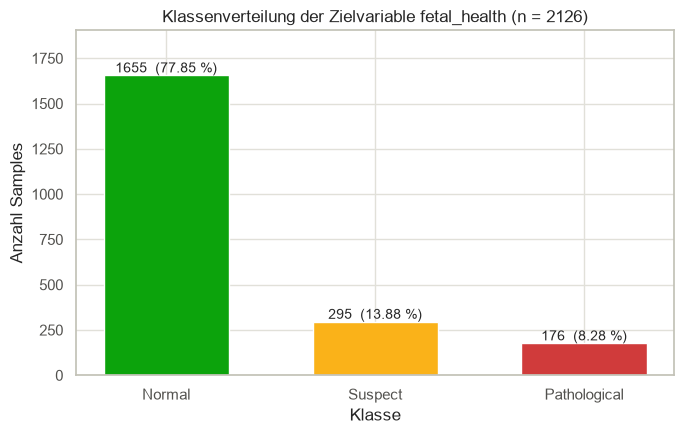

In [50]:
counts = df["fetal_health"].value_counts().sort_index()
dist = pd.DataFrame({
    "Klasse": [CLASS_NAMES[c] for c in counts.index],
    "Anzahl": counts.values,
    "Anteil (%)": (counts.values / len(df) * 100).round(2),
}, index=counts.index.astype(int))
dist.index.name = "Code"
display(dist)

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(dist["Klasse"], dist["Anzahl"],
              color=[CLASS_COLORS[k] for k in dist["Klasse"]], width=0.6)
for bar, n, p in zip(bars, dist["Anzahl"], dist["Anteil (%)"]):
    ax.annotate(f"{n}  ({p} %)",
                (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                ha="center", va="bottom", fontsize=10)
ax.set_title("Klassenverteilung der Zielvariable fetal_health (n = 2126)")
ax.set_xlabel("Klasse")
ax.set_ylabel("Anzahl Samples")
ax.set_ylim(0, dist["Anzahl"].max() * 1.15)
plt.tight_layout()
plt.show()

### Beobachtungen zur Klassenverteilung: Wie ausgewogen sind die Klassen?

| Klasse | absolut | prozentual |
|---|---|---|
| 1 = Normal | 1.655 | 77,85 % |
| 2 = Suspect | 295 | 13,88 % |
| 3 = Pathological | 176 | 8,28 % |

Die Klassen sind stark imbalanciert; das Verhältnis der größten zur kleinsten Klasse liegt bei
etwa 9,4 zu 1. Das deckt sich mit der Angabe im Assignment von ungefähr 78 / 14 / 8 %. Daraus
ziehen wir vier Konsequenzen:

1. **Naive Baseline.** Ein Modell, das immer „Normal“ vorhersagt, erreicht schon rund 77,9 %
   Accuracy. Jede Modellbewertung muss sich an dieser Marke messen lassen, Accuracy allein ist
   hier also trügerisch.
2. **Metriken.** Wir berichten durchgängig zusätzlich F1 (weighted) und je Klasse Precision und
   Recall über den `classification_report`. Besonders kritisch ist der Recall der Klasse
   Pathological, denn übersehene Pathologien sind im Praxiskontext am teuersten.
3. **Splits.** Train/Validation/Test-Split und Kreuzvalidierung laufen stratifiziert, damit die
   kleinen Klassen, vor allem Pathological mit nur 176 Fällen, in jeder Teilmenge im gleichen
   Verhältnis vertreten sind.
4. **Modellbildung.** `class_weight="balanced"` beziehungsweise Klassengewichte halten wir uns
   als begründeten Freiheitsgrad für Schritt 3 und 6 offen.

## 1.5 Visualisierung 1: Verteilung der numerischen Features (Histogramme)

Histogramme aller 21 Features geben einen Überblick über Verteilungsformen (symmetrisch oder
schief), Wertebereiche und Besonderheiten.

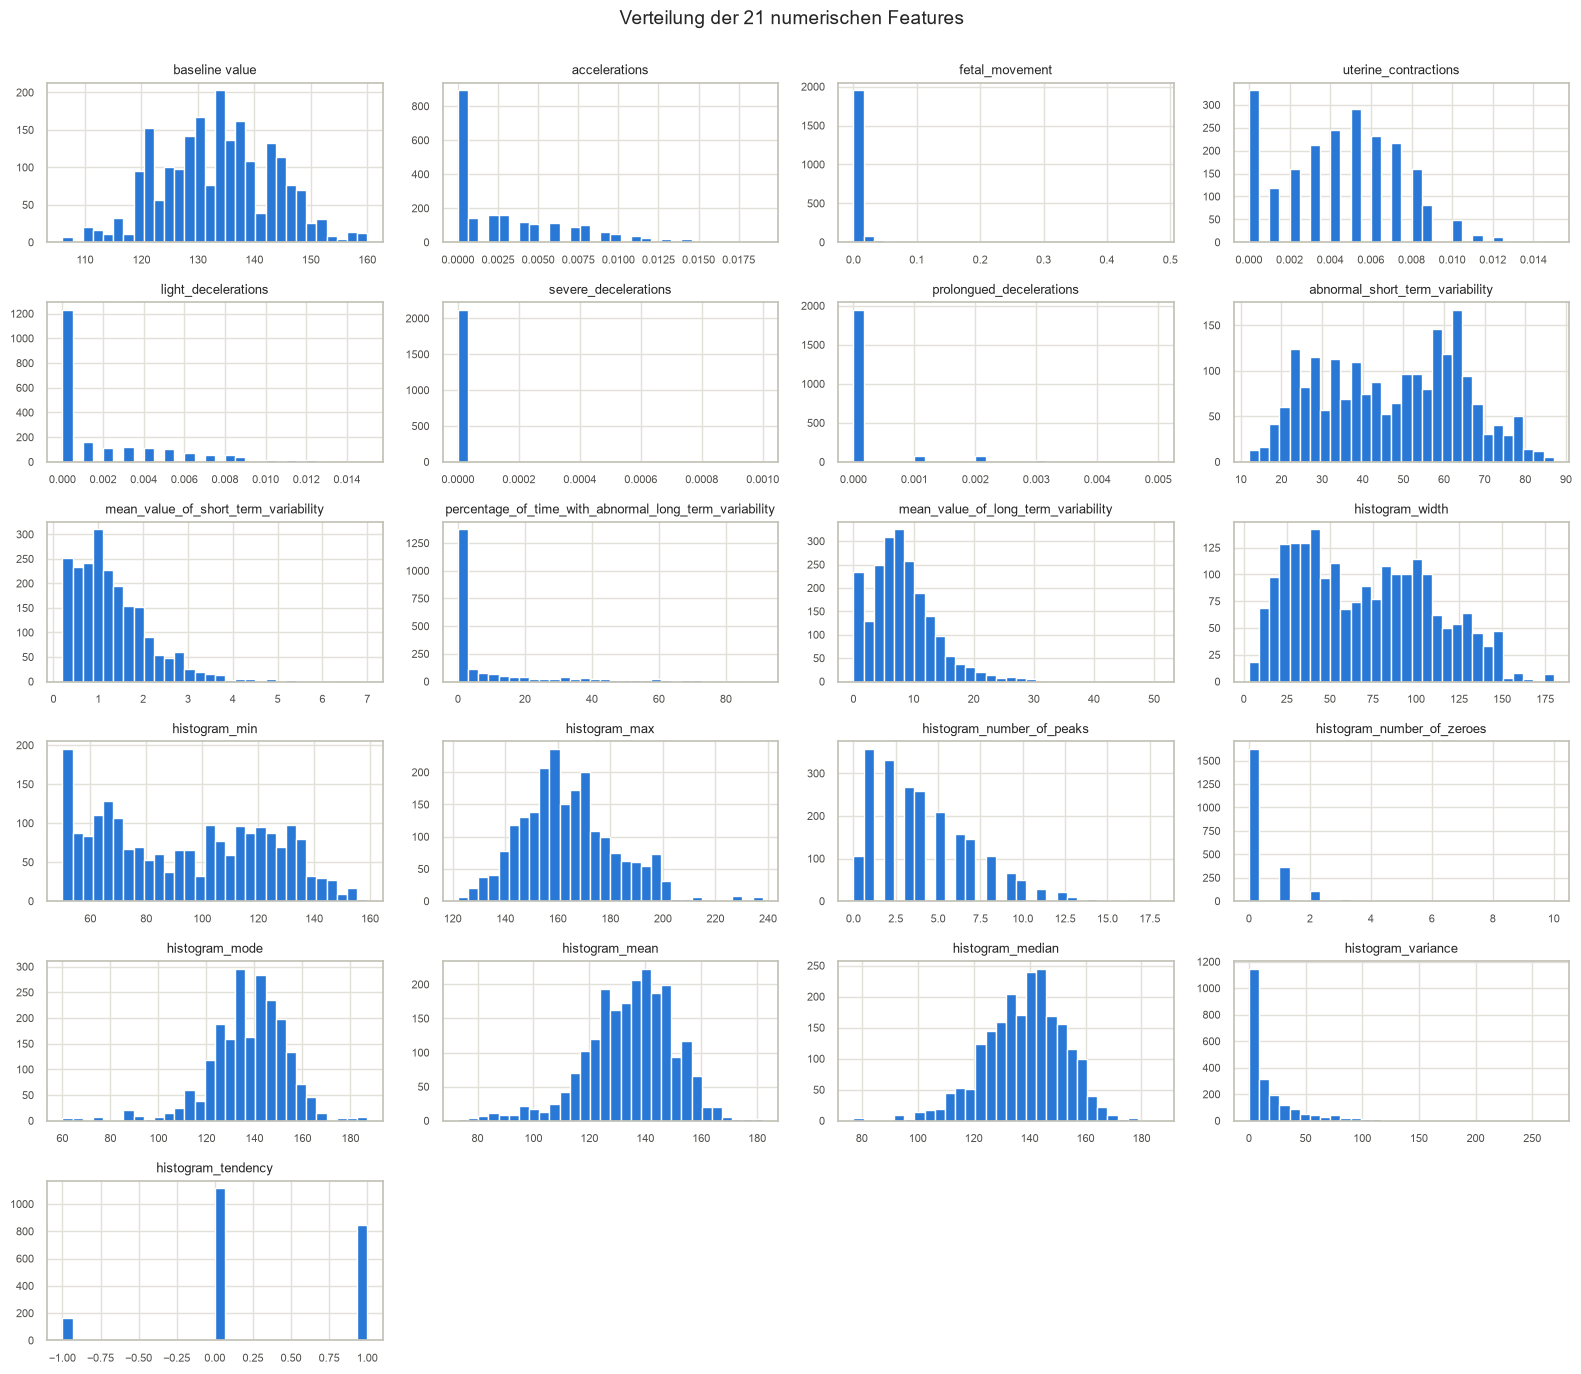

In [51]:
features = df.drop(columns="fetal_health")

axes = features.hist(bins=30, figsize=(16, 14), layout=(6, 4),
                     color="#2a78d6", edgecolor="white", grid=True)
for ax in axes.ravel():
    ax.set_title(ax.get_title(), fontsize=9)
    ax.tick_params(labelsize=8)
fig = plt.gcf()
fig.suptitle("Verteilung der 21 numerischen Features", fontsize=14)
fig.tight_layout(rect=(0, 0, 1, 0.98))
plt.show()

### Beobachtungen zu den Feature-Verteilungen

Annähernd symmetrisch und glockenförmig verteilt sind `baseline value`, `histogram_mode`,
`histogram_mean` und `histogram_median`, also die klassischen Lageparameter der Herzfrequenz.

Stark rechtsschief beziehungsweise von Nullen dominiert sind `fetal_movement`,
`light_decelerations`, `severe_decelerations`, `prolongued_decelerations`, `histogram_variance`
und `percentage_of_time_with_abnormal_long_term_variability`. Das sind seltene Ereignisse, die
nur bei einem Teil der CTGs auftreten.

Zwei Features sind faktisch ordinal, obwohl sie als `float64` gespeichert sind:
`histogram_tendency` nimmt nur die Werte −1, 0 und 1 an (Tendenz des FHR-Histogramms:
linksschief, symmetrisch, rechtsschief), `histogram_number_of_zeroes` nur kleine ganze Zahlen.
Da die Werte bereits numerisch und sinnvoll geordnet sind, brauchen wir keine One-Hot-Kodierung
und behandeln sie als numerische Features (siehe ADR-006).

`severe_decelerations` ist quasi-konstant, nur 7 von 2.126 Zeilen sind ungleich 0. Für die
meisten Modelle trägt das Feature damit kaum Information. Wir behalten es trotzdem, weil
Baumverfahren und regularisierte Modelle damit umgehen können und der klinische Informationsgehalt
im Einzelfall hoch ist: Schwere Dezelerationen sind ein akutes Warnzeichen.

Die sehr unterschiedlichen Größenordnungen, etwa `accelerations` mit rund 10⁻³ gegenüber
`histogram_max` mit rund 10², bestätigen noch einmal, dass wir in Schritt 2 standardisieren
müssen.

## 1.6 Visualisierung 2: Korrelationsmatrix der numerischen Features

Die Pearson-Korrelationsmatrix zeigt lineare Zusammenhänge zwischen den Features, also
Multikollinearität, und gibt erste Hinweise auf den Zusammenhang mit der Zielvariable. Die obere
Dreieckshälfte blenden wir aus, weil sie dieselbe Information spiegelbildlich wiederholt.

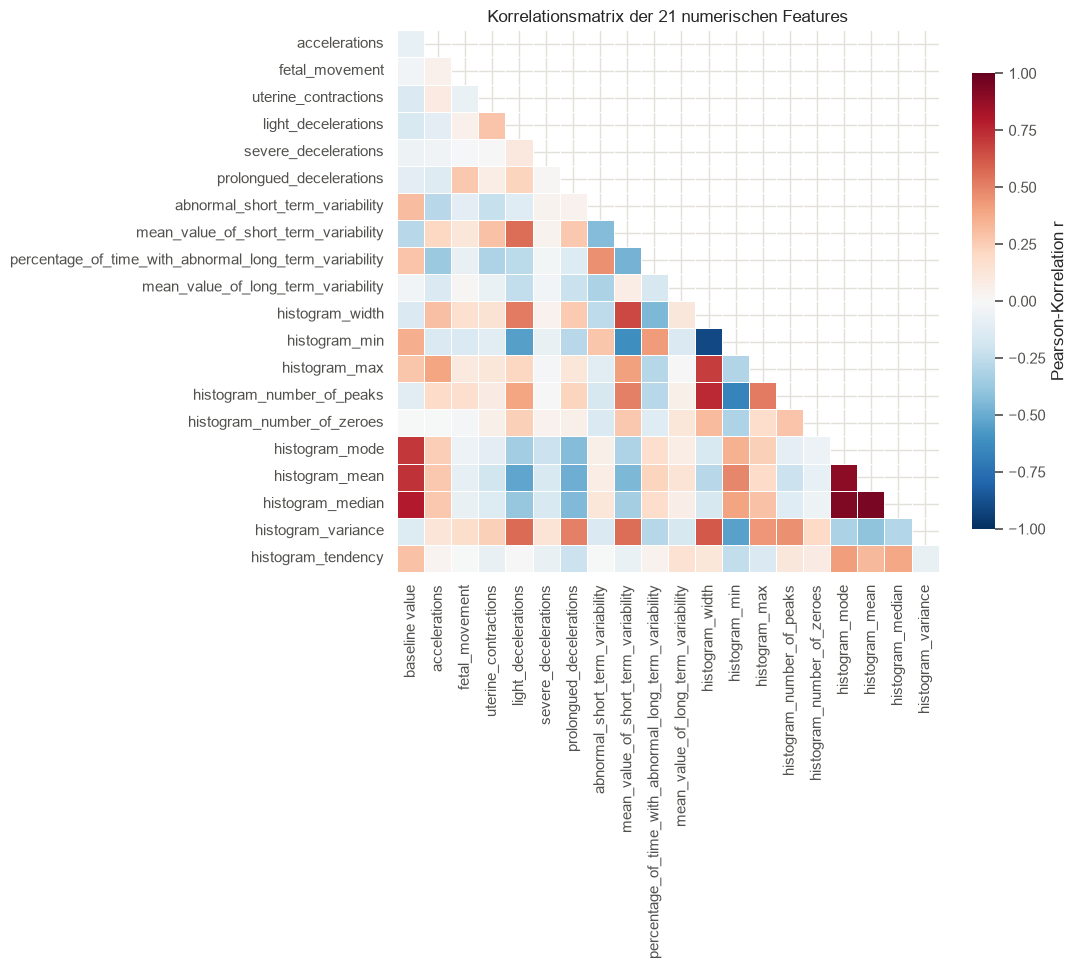

Feature-Paare mit |r| >= 0.8:


,,r
histogram_mean,histogram_median,0.948
histogram_mode,histogram_median,0.933
histogram_width,histogram_min,-0.899
histogram_mode,histogram_mean,0.893


In [52]:
corr = features.corr()

# Nur die untere Dreieckshälfte zeigen: die obere ist spiegelbildlich redundant,
# die Diagonale ist konstant 1. Erste Zeile / letzte Spalte wären danach leer -> abschneiden.
corr_lower = corr.iloc[1:, :-1]
mask = np.triu(np.ones_like(corr_lower, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(11, 11))
sns.heatmap(corr_lower, mask=mask, cmap="RdBu_r", vmin=-1, vmax=1, center=0,
            square=True, linewidths=0.5, linecolor="white",
            cbar_kws={"label": "Pearson-Korrelation r", "shrink": 0.6}, ax=ax)
ax.set_title("Korrelationsmatrix der 21 numerischen Features")
plt.tight_layout()
plt.show()

# Feature-Paare mit sehr starkem linearem Zusammenhang (Multikollinearität)
strong_pairs = (corr.where(np.triu(np.ones_like(corr, dtype=bool), k=1).astype(bool))
                    .stack()
                    .loc[lambda s: s.abs() >= 0.8]
                    .sort_values(key=abs, ascending=False))
print("Feature-Paare mit |r| >= 0.8:")
display(strong_pairs.round(3).to_frame("r"))

Zusätzlich betrachten wir gezielt die Korrelation jedes Features mit der Zielvariable.
`fetal_health` ist ordinal (1 < 2 < 3), die Pearson-Korrelation ist hier also nur eine Heuristik
zur Vorauswahl: Nicht-monotone Zusammenhänge unterschätzt sie systematisch, siehe Abschnitt 1.7.
Die exakten Werte stehen in der Tabelle, das Diagramm zeigt das Ranking.

,r zu fetal_health
prolongued_decelerations,0.485
abnormal_short_term_variability,0.471
percentage_of_time_with_abnormal_long_term_variability,0.426
accelerations,-0.364
histogram_mode,-0.250
histogram_mean,-0.227
mean_value_of_long_term_variability,-0.227
histogram_variance,0.207
histogram_median,-0.205
uterine_contractions,-0.205


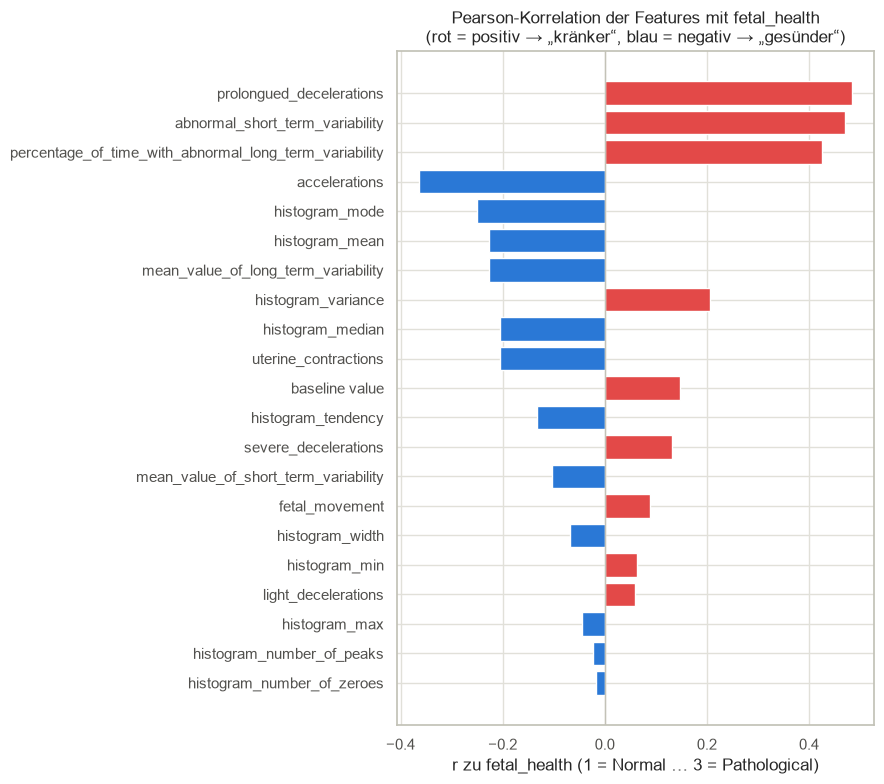

In [53]:
target_corr = df.corr()["fetal_health"].drop("fetal_health")
ranking = target_corr.reindex(target_corr.abs().sort_values(ascending=False).index)
display(ranking.round(3).to_frame("r zu fetal_health"))

plot_order = ranking.iloc[::-1]  # barh zeichnet von unten nach oben, also umdrehen
fig, ax = plt.subplots(figsize=(9, 8))
colors = ["#e34948" if v > 0 else "#2a78d6" for v in plot_order]
ax.barh(plot_order.index, plot_order.values, color=colors)
ax.axvline(0, color="#c3c2b7", linewidth=1)
ax.set_title("Pearson-Korrelation der Features mit fetal_health\n"
             "(rot = positiv → „kränker“, blau = negativ → „gesünder“)")
ax.set_xlabel("r zu fetal_health (1 = Normal … 3 = Pathological)")
plt.tight_layout()
plt.show()

### Beobachtungen zu den Korrelationen

**Zusammenhang mit der Zielvariable.** Am stärksten steigen `prolongued_decelerations`
(r = +0,49), `abnormal_short_term_variability` (+0,47) und
`percentage_of_time_with_abnormal_long_term_variability` (+0,43) mit dem Schweregrad. Klinisch
ist das plausibel, denn verlängerte Dezelerationen und abnorme Variabilität sind bekannte
Warnzeichen. `accelerations` sinkt umgekehrt mit dem Schweregrad (−0,36): Das *Fehlen* von
Akzelerationen ist der Risikomarker. Danach folgen die Histogramm-Lageparameter
(`histogram_mode` −0,25, `histogram_mean` −0,23, `histogram_median` −0,21) sowie
`mean_value_of_long_term_variability` (−0,23), `histogram_variance` (+0,21) und
`uterine_contractions` (−0,21).

**Multikollinearität zwischen den Features.** `histogram_mode`, `histogram_mean` und
`histogram_median` korrelieren untereinander sehr stark (r zwischen 0,89 und 0,95); sie messen
fast dasselbe, nämlich die Lage der FHR-Verteilung. `histogram_width` und `histogram_min`
korrelieren mit r von etwa −0,90: Ein breites Histogramm geht mit einem niedrigen Minimum
einher.

Für die Logistische Regression bedeutet das, dass einzelne Koeffizienten schwer interpretierbar
und instabil werden; die Vorhersagegüte leidet in der Regel wenig. Baumverfahren sind gegenüber
Multikollinearität robust. Wir entfernen deshalb keine Features vorab, merken die Redundanz aber
als möglichen Vereinfachungshebel für Schritt 6 und 7 vor (siehe ADR-005).

## 1.7 Visualisierung 3: Zusammenhang zwischen Features und Zielklassen

Boxplots der acht Features mit der höchsten absoluten Korrelation zur Zielvariable, getrennt
nach Klasse. Sie zeigen auch nicht-monotone Muster, die die Pearson-Korrelation verdeckt.

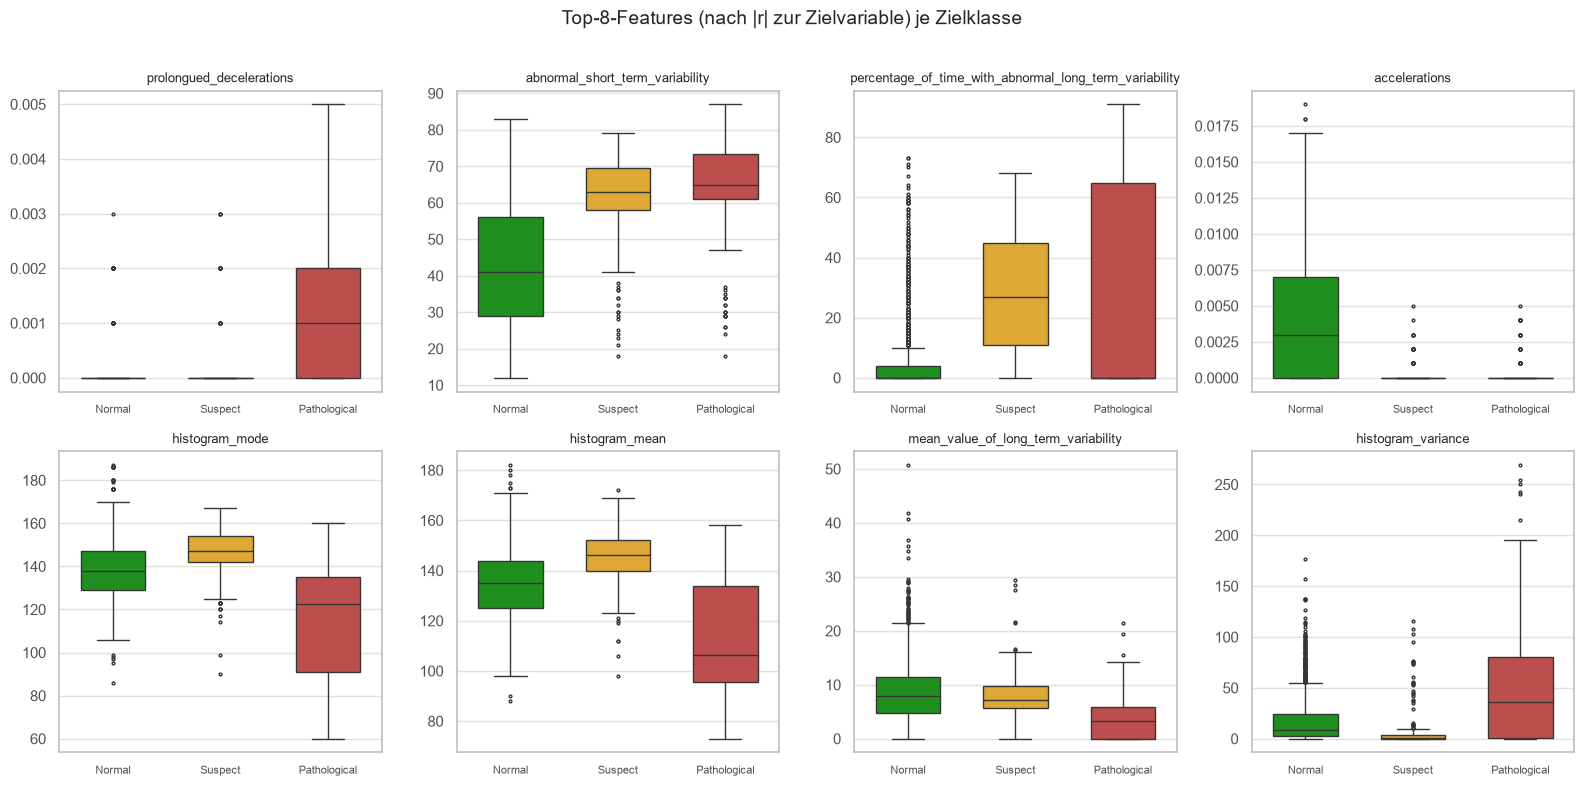

In [54]:
top_features = target_corr.abs().sort_values(ascending=False).head(8).index.tolist()

df_plot = df.copy()
df_plot["Klasse"] = df_plot["fetal_health"].map(CLASS_NAMES)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, feat in zip(axes.ravel(), top_features):
    sns.boxplot(data=df_plot, x="Klasse", y=feat, order=CLASS_ORDER,
                hue="Klasse", hue_order=CLASS_ORDER, palette=CLASS_COLORS,
                legend=False, width=0.6, fliersize=2, ax=ax)
    ax.set_title(feat, fontsize=9)
    ax.set_xlabel("")
    ax.set_ylabel("")  # Feature-Name steht bereits im Titel -> lange Labels weglassen
    ax.tick_params(axis="x", labelsize=8)
fig.suptitle("Top-8-Features (nach |r| zur Zielvariable) je Zielklasse", fontsize=14)
fig.tight_layout(rect=(0, 0, 1, 0.97))
plt.show()

In [55]:
# Mediane der Top-8-Features je Klasse (Zahlenbasis für die Interpretation)
medians = df_plot.groupby("Klasse")[top_features].median().reindex(CLASS_ORDER)
medians.T.round(4)

Klasse,Normal,Suspect,Pathological
prolongued_decelerations,0.000,0.0,0.001
abnormal_short_term_variability,41.000,63.0,65.000
percentage_of_time_with_abnormal_long_term_variability,0.000,27.0,0.000
accelerations,0.003,0.0,0.000
histogram_mode,138.000,147.0,122.500
histogram_mean,135.000,146.0,106.500
mean_value_of_long_term_variability,8.000,7.1,3.250
histogram_variance,9.000,1.0,36.500


### Beobachtungen zum Feature-Klassen-Zusammenhang

`abnormal_short_term_variability` trennt am klarsten: Der Median steigt von 41 bei Normal über
63 bei Suspect auf 65 bei Pathological.

Bei `accelerations` zeigen normale CTGs Akzelerationen (Median 0,003 pro Sekunde), Suspect- und
Pathological-CTGs praktisch keine (Median 0). Wieder ist das Fehlen das Warnzeichen.
`prolongued_decelerations` tritt fast ausschließlich bei Pathological auf (Median 0,001 pro
Sekunde gegenüber 0 bei beiden anderen Klassen), ist also selten, aber hochspezifisch.

`percentage_of_time_with_abnormal_long_term_variability` ist vor allem bei Suspect erhöht
(Median 27 gegenüber 0). Bei Pathological ist die Verteilung zweigeteilt (Median 0, Mittelwert
rund 23): Ein Teil der pathologischen CTGs zeigt dieses Muster stark, ein anderer gar nicht.

Besonders interessant sind die nicht-monotonen Zusammenhänge, die Pearson unterschätzt.
`histogram_mean` und `histogram_mode` liegen bei Suspect *höher* als bei Normal (rund 146 / 147
gegenüber 135 / 138), bei Pathological dagegen deutlich *niedriger* (rund 106 / 122, also
Tendenz zur Bradykardie). Ähnlich verhält sich `histogram_variance`: Suspect ist am niedrigsten
(Median 1), Pathological am höchsten (Median 36,5). Solche U-förmigen Muster sprechen dafür,
dass nichtlineare Modelle wie Baumverfahren und Netze hier Vorteile gegenüber der Logistischen
Regression haben könnten.

`mean_value_of_long_term_variability` ist bei Pathological deutlich reduziert (Median 3,25
gegenüber 8,0 bei Normal). Auch das passt: eingeschränkte Variabilität als Risikomarker.

## 1.8 Fazit Schritt 1: Welche Features erscheinen besonders relevant?

Als besonders relevant schätzen wir die folgenden Features ein. Das Kriterium war jeweils eine
Kombination aus hoher absoluter Korrelation zur Zielvariable, klarer Klassentrennung in den
Boxplots und klinischer Plausibilität.

1. `abnormal_short_term_variability`, die stärkste und nahezu monotone Trennung aller drei Klassen
2. `prolongued_decelerations`, hochspezifisch für Pathological
3. `percentage_of_time_with_abnormal_long_term_variability`, markiert vor allem Suspect
4. `accelerations`, wobei hier das Fehlen der Risikomarker ist (negativer Zusammenhang)
5. `histogram_mean`, `histogram_mode` und `histogram_median`, die Pathological über die
   Bradykardie-Tendenz trennen, allerdings nicht-monoton und untereinander redundant (r um 0,9)
6. `mean_value_of_long_term_variability` und `histogram_variance` als ergänzende
   Variabilitätsmarker

Das ist ausdrücklich eine Hypothese aus der explorativen Analyse. Verlässliche Aussagen über
Feature-Wichtigkeit liefern erst die Modelle, etwa die Feature Importances des Baumverfahrens in
Schritt 3 und 6.

**Was folgt daraus für die nächsten Schritte?** In Schritt 2 entfernen wir die 13 Duplikate vor
dem Split, brauchen keine Imputation und keine Feature-Kodierung, mappen die Zielvariable mit
dem `LabelEncoder` auf 0/1/2, splitten stratifiziert im Verhältnis 70/15/15 und fitten den
`StandardScaler` ausschließlich auf den Trainingsdaten. Ab Schritt 3 bewerten wir primär über
F1 (weighted) und den `classification_report` mit besonderem Augenmerk auf den Recall der Klasse
Pathological, und ordnen die Accuracy immer gegen die 77,9-%-Baseline „immer Normal“ ein. Und
weil die Zusammenhänge teils nicht-monoton sind, könnten nichtlineare Modelle im Vorteil sein.

---
# Schritt 2: Preprocessing und Datenvorbereitung

Laut Assignment umfasst Schritt 2:

1. Fehlende Werte identifizieren, behandeln und Entscheidung begründen
2. Kategorische Features kodieren (One-Hot oder Label Encoding, mit Begründung)
3. Zielvariable mit `LabelEncoder` in Integer-Codes umwandeln und das Mapping dokumentieren
4. Stratifizierten Train/Validation/Test-Split (70 / 15 / 15) durchführen
5. Features skalieren: welche und warum?
6. Frage beantworten: Darf der Scaler auf dem gesamten Datensatz gefittet werden?

Zusätzlich setzen wir hier die Entscheidung aus Schritt 1 um und entfernen die 13
Duplikat-Zeilen vor dem Split (siehe ADR-004).

## 2.1 Fehlende Werte identifizieren und behandeln

Die Prüfung aus Schritt 1.2 führen wir hier noch einmal explizit als Preprocessing-Schritt aus,
weil das Assignment die Behandlung fehlender Werte in Schritt 2 verlangt.

In [56]:
missing = df.isna().sum()
print("Fehlende Werte gesamt:      ", missing.sum())
print("Spalten mit fehlenden Werten:", (missing > 0).sum(), "von", df.shape[1])

Fehlende Werte gesamt:       0
Spalten mit fehlenden Werten: 0 von 22


**Entscheidung (ADR-003): keine Imputation.** Der Datensatz enthält in keiner der 2.126 × 22
Zellen einen fehlenden Wert, es gibt also schlicht nichts zu behandeln. Jede Imputationsstrategie,
ob Mittelwert, Median oder k-NN, würde nur Komplexität und eine potenzielle Fehlerquelle
einführen, ohne einen einzigen Wert zu ändern. Die Prüfung bleibt trotzdem bewusst als Codezelle
im Notebook, um den geforderten Nachweis zu erbringen. Bei einem Datensatz-Update würde sie
sofort anschlagen.

## 2.2 Duplikate entfernen, vor dem Split

Hier setzen wir die Entscheidung aus Schritt 1.2 um (siehe ADR-004). Identische Zeilen könnten
durch den zufälligen Split gleichzeitig im Trainings- und im Validierungs- oder Testset landen.
Das Modell würde dann auf Daten bewertet, die es exakt so schon gesehen hat, und die gemessene
Generalisierungsleistung wäre leakage-artig überschätzt. Deshalb muss das Entfernen vor dem Split
geschehen.

In [57]:
print("Zeilen vor dem Entfernen: ", len(df))
df_clean = df.drop_duplicates().reset_index(drop=True)
print("Zeilen nach dem Entfernen:", len(df_clean),
      f"  ({len(df) - len(df_clean)} Duplikate entfernt)")

class_counts = df_clean["fetal_health"].value_counts().sort_index()
print("\nKlassenverteilung nach der Duplikat-Entfernung:")
print(pd.DataFrame({
    "Klasse": [CLASS_NAMES[c] for c in class_counts.index],
    "n": class_counts.values,
    "%": (class_counts.values / len(df_clean) * 100).round(2),
}).to_string(index=False))

Zeilen vor dem Entfernen:  2126
Zeilen nach dem Entfernen: 2113   (13 Duplikate entfernt)

Klassenverteilung nach der Duplikat-Entfernung:
      Klasse    n     %
      Normal 1646 77.90
     Suspect  292 13.82
Pathological  175  8.28


Es verbleiben 2.113 Zeilen. Die Klassenverteilung ändert sich dadurch praktisch nicht
(77,90 / 13,82 / 8,28 % statt 77,85 / 13,88 / 8,28 %), die Duplikate waren also nicht auf eine
Klasse konzentriert. Ab hier arbeiten wir ausschließlich mit `df_clean`.

## 2.3 Kategorische Features kodieren?

Das Assignment verlangt eine begründete Kodierungs-Entscheidung zwischen One-Hot und Label
Encoding. Dazu prüfen wir Datentypen und Kardinalität, also die Anzahl unterschiedlicher Werte
je Feature.

In [58]:
print("Datentypen im Datensatz:", df_clean.dtypes.unique().tolist())
print("\nFeatures mit den wenigsten unterschiedlichen Werten:")
print(df_clean.nunique().sort_values().head(6).to_string())
print("\nWerte von histogram_tendency:", sorted(df_clean["histogram_tendency"].unique()))

Datentypen im Datensatz: [dtype('float64')]

Features mit den wenigsten unterschiedlichen Werten:
severe_decelerations           2
fetal_health                   3
histogram_tendency             3
prolongued_decelerations       6
histogram_number_of_zeroes     9
uterine_contractions          16

Werte von histogram_tendency: [np.float64(-1.0), np.float64(0.0), np.float64(1.0)]


**Entscheidung (ADR-006): keine Feature-Kodierung.** Dafür sprechen drei Beobachtungen.

Erstens gibt es keine Text- oder String-Features, alle 21 Features liegen als `float64` vor. Der
klassische Anwendungsfall für One-Hot- oder Label-Encoding entfällt damit vollständig.

Zweitens ist das einzige kategorial *wirkende* Feature `histogram_tendency` mit den drei Werten
−1, 0 und 1 (Tendenz des FHR-Histogramms: linksschief, symmetrisch, rechtsschief). Es ist ordinal
mit sinnvoller Ordnung und bereits passend numerisch kodiert. Ein One-Hot-Encoding würde die
Ordnungsinformation zerstören und ohne Not drei Spalten erzeugen, also behalten wir die
numerische Darstellung.

Drittens sind `severe_decelerations` mit 2 Ausprägungen und `histogram_number_of_zeroes` mit 9
Ausprägungen echte Zähl- und Messgrößen mit sinnvollen numerischen Abständen. Auch hier ist keine
Kodierung nötig.

## 2.4 Zielvariable kodieren (`LabelEncoder`) und Mapping dokumentieren

Die Zielvariable liegt als 1.0 / 2.0 / 3.0 im Typ `float64` vor, Klassentexte gibt es keine. Wir
kodieren sie trotzdem wie im Assignment gefordert mit dem `LabelEncoder` auf die Integer-Codes
0 / 1 / 2, und zwar aus zwei Gründen.

scikit-learn und Keras erwarten 0-basierte Integer-Klassen. Insbesondere setzt die
Verlustfunktion `sparse_categorical_crossentropy` aus Schritt 4 und 5 Codes von 0 bis
n_classes − 1 voraus. Außerdem macht der gefittete Encoder das Mapping explizit und erlaubt
später die Rückübersetzung der Vorhersagen über `inverse_transform`.

In [59]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df_clean["fetal_health"])
X = df_clean.drop(columns="fetal_health")

# Klassennamen in Code-Reihenfolge (0, 1, 2) - wird in allen folgenden Schritten verwendet
TARGET_NAMES = [CLASS_NAMES[c] for c in label_encoder.classes_]

mapping = pd.DataFrame({
    "Originalwert (fetal_health)": label_encoder.classes_,
    "Klasse": TARGET_NAMES,
}, index=pd.Index(range(len(label_encoder.classes_)), name="Code"))
display(mapping)

print("X:", X.shape, "| y:", y.shape, "| Klassen in y:", np.unique(y))

,Originalwert (fetal_health),Klasse
Code,,
0,1.0,Normal
1,2.0,Suspect
2,3.0,Pathological


X: (2113, 21) | y: (2113,) | Klassen in y: [0 1 2]


Damit ist das Mapping dokumentiert: Normal (1.0) wird zu **0**, Suspect (2.0) zu **1** und
Pathological (3.0) zu **2**. Der `LabelEncoder` sortiert die Originalwerte aufsteigend, die
medizinische Ordnung des Schweregrads bleibt also erhalten.

## 2.5 Stratifizierter Train / Validation / Test-Split (70 / 15 / 15)

`train_test_split` kann nur zweiteilen, deshalb splitten wir zweistufig: zuerst 70 % Train gegen
30 % Rest, dann den Rest hälftig in Validation und Test mit je 15 % der Gesamtdaten. Beide Stufen
sind über `stratify` stratifiziert und über `RANDOM_STATE` reproduzierbar (siehe ADR-009).

Warum ist die Stratifizierung hier besonders wichtig? Die kleinste Klasse Pathological hat nur
175 von 2.113 Fällen. Bei einem rein zufälligen Split könnte das 15-%-Testset deutlich zu wenige
oder zu viele davon enthalten, und die Metriken der klinisch wichtigsten Klasse wären dann ein
Zufallsprodukt. Stratifizierung erzwingt in allen drei Teilmengen dieselben Klassenanteile.

Die drei Teilmengen haben klar getrennte Rollen: Trainiert wird auf *Train*, alle
Modellvergleiche aus Schritt 3 bis 6 und die Hyperparameter-Optimierung laufen über
*Validation*, und das *Testset* fassen wir genau einmal an, nämlich bei der finalen Evaluation
in Schritt 6.

In [60]:
from sklearn.model_selection import train_test_split

# Stufe 1: 70 % Train / 30 % Rest
X_train, X_rest, y_train, y_rest = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE)

# Stufe 2: Rest hälftig in Validation und Test (je 15 % der Gesamtdaten)
X_val, X_test, y_val, y_test = train_test_split(
    X_rest, y_rest, test_size=0.50, stratify=y_rest, random_state=RANDOM_STATE)

# Kontrolle: Größen und Klassenanteile je Teilmenge
rows = {}
for name, y_part in [("Train", y_train), ("Validation", y_val), ("Test", y_test)]:
    class_counts = pd.Series(y_part).value_counts().sort_index()
    rows[(name, "n")] = class_counts
    rows[(name, "%")] = (class_counts / len(y_part) * 100).round(2)
split_overview = pd.DataFrame(rows)
split_overview.index = [f"{code} = {name}" for code, name in enumerate(TARGET_NAMES)]
print(f"Train: {len(y_train)}  |  Validation: {len(y_val)}  |  Test: {len(y_test)}")
display(split_overview)

Train: 1479  |  Validation: 317  |  Test: 317


Train        Validation        Test       
                     n      %          n      %    n      %
0 = Normal        1152  77.89        247  77.92  247  77.92
1 = Suspect        204  13.79         44  13.88   44  13.88
2 = Pathological   123   8.32         26   8.20   26   8.20

Der Split ergibt 1.479 / 317 / 317 Samples. Die Klassenanteile sind in allen drei Teilmengen
nahezu identisch (Normal rund 77,9 %, Suspect rund 13,8 %, Pathological 8,2 bis 8,3 %), die
Stratifizierung funktioniert also.

Eine Einschränkung müssen wir für später mitnehmen: Validation und Test enthalten je nur 26
Pathological-Fälle. Ein einziger falsch klassifizierter Fall verändert den Recall dieser Klasse
bereits um rund 3,8 Prozentpunkte. Metrik-Unterschiede in dieser Größenordnung dürfen wir in
Schritt 6 und 7 nicht überinterpretieren.

## 2.6 Features skalieren: welche und warum?

**Welche Features?** Alle 21. Sie sind sämtlich numerisch und liegen auf sehr unterschiedlichen
Skalen, wie Schritt 1.3 gezeigt hat: `accelerations` zwischen 0 und 0,02, `baseline value`
zwischen 106 und 160, `histogram_variance` zwischen 0 und 269.

**Warum?** Ohne Skalierung dominieren die betragsmäßig großen Features die distanzbasierten
Verfahren wie k-NN und SVM und erschweren die gradientenbasierte Optimierung bei Logistischer
Regression und neuronalen Netzen. Hochinformative, aber kleine Features wie `accelerations`
gingen dabei praktisch unter.

**Warum `StandardScaler` und nicht `MinMaxScaler`?** Wir haben in Schritt 1 bewusst entschieden,
Extremwerte zu behalten (siehe ADR-007), weil sie hier diagnostisch relevant sind. MinMax
skaliert auf den Bereich [0, 1] zwischen Minimum und Maximum und reagiert damit maximal
empfindlich auf genau diese Extremwerte: Ein einzelner Ausreißer staucht alle übrigen Werte
zusammen. Die Standardisierung auf Mittelwert 0 und Standardabweichung 1 ist dagegen deutlich
robuster und im Kurs die empfohlene Wahl für Logistische Regression, SVM und neuronale Netze
(siehe ADR-008).

**Für welche Modelle?** Die skalierten Daten nutzen Logistische Regression, k-NN oder SVM und
die beiden MLPs. Das Baumverfahren aus Schritt 3 bekommt die unskalierten Daten, denn Bäume
splitten auf Schwellenwerten einzelner Features und sind skaleninvariant. Beide Varianten bleiben
deshalb erhalten.

In [61]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# fit_transform nur auf Train. Validation und Test werden ausschließlich transformiert.
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train),
                              columns=X_train.columns, index=X_train.index)
X_val_scaled = pd.DataFrame(scaler.transform(X_val),
                            columns=X_val.columns, index=X_val.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test),
                             columns=X_test.columns, index=X_test.index)

# Kontrolle: Train hat exakt Mittelwert 0 und Std 1, Validation nur ungefähr
print("Train (skaliert):      max. |Mittelwert| =",
      f"{X_train_scaled.mean().abs().max():.2e}",
      "| mittlere Std =", X_train_scaled.std(ddof=0).mean().round(4))
print("Validation (skaliert): Mittelwerte von",
      X_val_scaled.mean().min().round(3), "bis", X_val_scaled.mean().max().round(3))

Train (skaliert):      max. |Mittelwert| = 9.13e-16 | mittlere Std = 1.0
Validation (skaliert): Mittelwerte von -0.096 bis 0.116


Die Kontrolle zeigt das erwartete Bild. Die Trainingsdaten haben nach der Skalierung exakt
Mittelwert 0 und Standardabweichung 1, denn auf ihnen wurde gefittet. Die Validierungsdaten
weichen leicht davon ab, ihre Mittelwerte liegen zwischen etwa −0,10 und +0,12. Genau so soll es
sein, denn sie wurden nur mit den *Trainings*-Parametern transformiert.

## 2.7 Darf der Scaler auf dem gesamten Datensatz gefittet werden?

**Nein.**

`StandardScaler` lernt beim Fitten Parameter aus den Daten, nämlich Mittelwert und
Standardabweichung jedes Features. Würden diese Parameter auf dem gesamten Datensatz berechnet,
flösse Information aus dem Validierungs- und Testset in die Vorverarbeitung der Trainingsdaten
ein. Das ist Data Leakage, und zwar aus drei Gründen problematisch.

Validierungs- und Testset sollen zukünftige, unbekannte Daten simulieren. Im echten Einsatz,
wenn ein neues CTG in die Klinik kommt, existieren diese Daten beim Training noch gar nicht. Sie
dürfen die Trainingspipeline also auch im Experiment nicht beeinflussen. Die so gemessene
Leistung wäre systematisch zu optimistisch, und das unbemerkt: Der Fehler fällt nicht auf, weil
er alle Metriken gleichmäßig schönt. Die Kontrolle in 2.6 macht die korrekte Reihenfolge
sichtbar, denn nur Train hat exakt Mittelwert 0 und Std 1.

Für die Kreuzvalidierung in Schritt 3 gilt dasselbe Prinzip je Fold. Damit der Scaler in jedem
CV-Fold nur auf dem jeweiligen Trainings-Teil gefittet wird, kapseln wir Skalierung und Modell in
einer sklearn-`Pipeline`, so wie im Kurs in Kapitel 3 eingeführt, dort in der Kurzform
`make_pipeline` (siehe ADR-008).

## 2.8 Zwischenstand: Artefakte für die Modellierung

Nach Schritt 2 stehen folgende Objekte für die Schritte 3 bis 6 bereit:

| Objekt | Inhalt | Verwendung |
|---|---|---|
| `X_train`, `X_val`, `X_test` | unskalierte Features | Baumverfahren |
| `X_train_scaled`, `X_val_scaled`, `X_test_scaled` | standardisierte Features | LogReg, k-NN/SVM, MLPs |
| `y_train`, `y_val`, `y_test` | Integer-Codes 0/1/2 | alle Modelle |
| `label_encoder`, `TARGET_NAMES` | Mapping zwischen Code und Klassenname | Reports, Konfusionsmatrix |
| `scaler` | auf Train gefitteter StandardScaler | spätere Anwendung auf neue Daten |

In [62]:
print(f"{'Teilmenge':<12} {'X unskaliert':<15} {'X skaliert':<15} {'y':<6} Pathological")
for name, X_raw, X_scaled_part, y_part in [("Train", X_train, X_train_scaled, y_train),
                                           ("Validation", X_val, X_val_scaled, y_val),
                                           ("Test", X_test, X_test_scaled, y_test)]:
    print(f"{name:<12} {str(X_raw.shape):<15} {str(X_scaled_part.shape):<15} "
          f"{len(y_part):<6} {(y_part == 2).sum()}")

Teilmenge    X unskaliert    X skaliert      y      Pathological
Train        (1479, 21)      (1479, 21)      1479   123
Validation   (317, 21)       (317, 21)       317    26
Test         (317, 21)       (317, 21)       317    26


---
# Schritt 3: Klassische Modelle

Laut Assignment umfasst Schritt 3:

1. Alle drei klassischen Modelle mit **Default-Parametern** auf den Trainingsdaten trainieren
2. Evaluation mit **5-facher stratifizierter Kreuzvalidierung**
3. Je Modell Accuracy, F1 (weighted) und, falls sinnvoll, weitere Metriken berechnen
4. Ergebnisse in die Vergleichstabelle aus Schritt 6 eintragen
5. Kurzer Kommentar zu jedem Modell

Als „weitere Metrik“ berechnen wir durchgängig den Recall der Klasse Pathological. Nach unserer
Metrikstrategie (siehe ADR-002) ist er das fachliche Hauptkriterium, denn ein übersehener
pathologischer Fall ist im CTG-Screening die teuerste Fehlklassifikation.

## 3.1 Modellwahl und Begründung

**Modell 1 ist vorgegeben:** die multinomiale Logistische Regression. In aktuellen
scikit-learn-Versionen verwendet `LogisticRegression()` mit dem Default-Solver `lbfgs` bei mehr
als zwei Klassen automatisch die multinomiale Softmax-Formulierung, eine zusätzliche Einstellung
ist also nicht nötig.

**Modell 2, Wahl zwischen Decision Tree, Random Forest und XGBoost: wir nehmen den Random
Forest** (siehe ADR-011). Ein einzelner Entscheidungsbaum hat eine hohe Varianz und neigt ohne
Beschneidung stark zum Overfitting, wie in Kapitel 6 des Kurses gezeigt. Ein Random Forest
mittelt viele dekorrelierte Bäume über Bagging und zufällige Feature-Auswahl und generalisiert
dadurch deutlich stabiler, gerade bei den hier geforderten Default-Parametern. Er ist außerdem
robust gegenüber der Multikollinearität aus Schritt 1.6 und benötigt keine Skalierung, bekommt
also die unskalierten Daten. Die nicht-monotonen Zusammenhänge aus Schritt 1.7, etwa bei
`histogram_mean`, kann ein Baumensemble ohne Weiteres abbilden. XGBoost wäre ähnlich
leistungsfähig, war im Kurs aber als Praxisausblick eingeordnet und bringt eine externe
Abhängigkeit mit; der Random Forest ist Kernbestandteil von Kapitel 6.

**Modell 3, Wahl zwischen k-NN und SVM: wir nehmen die SVM mit RBF-Kernel** (siehe ADR-012). Bei
21 Dimensionen leidet k-NN unter dem Fluch der Dimensionalität, Abstände werden also wenig
aussagekräftig (Kurs, Kapitel 7). Bei imbalancierten Klassen benachteiligt das Mehrheitsvoting
von k-NN die kleinen Klassen zusätzlich systematisch, denn die Nachbarschaft ist fast immer von
„Normal“ dominiert. Die SVM maximiert stattdessen den Rand zwischen den Klassen und kann mit dem
RBF-Kernel nichtlineare Entscheidungsgrenzen bilden (Kurs, Kapitel 8). Beide Kandidaten brauchen
skalierte Features, und die Laufzeit ist bei n = 1.479 unkritisch.

In [63]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline

# Skalierungssensitive Modelle stecken in einer Pipeline mit StandardScaler:
# so wird der Scaler in der Kreuzvalidierung je Fold NUR auf dem Fold-Trainingsteil
# gefittet (kein Leakage, vgl. Abschnitt 2.7). Der Random Forest ist skaleninvariant
# und arbeitet direkt auf den unskalierten Daten.
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression()),   # Default: lbfgs, multinomial
    ]),
    "Random Forest": RandomForestClassifier(random_state=RANDOM_STATE),
    "SVM (RBF)": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC()),                  # Default: RBF-Kernel, C=1, gamma='scale'
    ]),
}
print("Modelle:", list(models))

Modelle: ['Logistic Regression', 'Random Forest', 'SVM (RBF)']


Zwei Anmerkungen zu den Default-Parametern: `random_state` beim Random Forest ist kein
inhaltlicher Eingriff, sondern fixiert nur den Zufall für die Reproduzierbarkeit (siehe ADR-001).
Und die Logistische Regression konvergiert auf den standardisierten Daten bereits mit dem Default
`max_iter=100` warnungsfrei, ein Eingriff ist also auch dort nicht nötig.

## 3.2 Evaluation mit 5-facher stratifizierter Kreuzvalidierung

Die Kreuzvalidierung läuft ausschließlich auf den Trainingsdaten mit 1.479 Samples. Das
Validierungsset bleibt für den Modellvergleich in 3.3 unberührt, das Testset bleibt bis Schritt 6
tabu. `StratifiedKFold` sorgt dafür, dass jeder der 5 Folds die Klassenanteile von 78 / 14 / 8 %
trägt. Pro Fold-Validierungsteil sind das nur etwa 25 Pathological-Fälle; ohne Stratifizierung
könnten es zufällig deutlich weniger sein.

Zu jeder Metrik liefert die Kreuzvalidierung Mittelwert und Standardabweichung über die 5 Folds.
Wir bekommen also nicht nur eine Punktschätzung, sondern auch ein Maß dafür, wie stabil ein
Modell gegenüber der zufälligen Datenaufteilung ist.

In [64]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer, recall_score

# Die Scorer-Schlüssel sind bewusst snake_case ohne Leerzeichen und Klammern.
# cross_validate und GridSearchCV bauen daraus Spaltennamen wie
# "mean_test_f1_weighted"; Leerzeichen darin machen jeden Spaltenzugriff
# fehleranfällig. Die lesbaren Namen kommen erst bei der Anzeige dazu.
scoring = {
    "accuracy": "accuracy",
    "f1_weighted": "f1_weighted",
    # Recall nur für die Klasse Pathological (Code 2)
    "recall_pathological": make_scorer(recall_score, labels=[2], average="macro"),
}
METRIC_LABELS = {
    "accuracy": "Accuracy",
    "f1_weighted": "F1 (weighted)",
    "recall_pathological": "Recall Pathological",
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_rows = {}
for name, model in models.items():
    cv_result = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring)
    cv_rows[name] = {
        METRIC_LABELS[m]: f"{cv_result[f'test_{m}'].mean():.4f} "
                          f"± {cv_result[f'test_{m}'].std():.4f}"
        for m in scoring
    }

cv_results = pd.DataFrame(cv_rows).T
cv_results.index.name = "5-fache stratifizierte CV (Trainingsdaten)"
display(cv_results)

,Accuracy,F1 (weighted),Recall Pathological
5-fache stratifizierte CV (Trainingsdaten),,,
Logistic Regression,0.8912 ± 0.0171,0.8901 ± 0.0163,0.7403 ± 0.0579
Random Forest,0.9365 ± 0.0144,0.9339 ± 0.0155,0.8620 ± 0.0697
SVM (RBF),0.8999 ± 0.0131,0.8960 ± 0.0139,0.7080 ± 0.0752


### Beobachtungen zur Kreuzvalidierung

Der Random Forest führt deutlich, mit Accuracy 0,937 ± 0,014 und F1w 0,934 ± 0,016, und er
erkennt auch die kritische Klasse am besten (Recall Pathological 0,862 ± 0,070). SVM (RBF) und
Logistische Regression liegen bei der Accuracy nahe beieinander (0,900 beziehungsweise 0,891),
beide erkennen Pathological aber deutlich schlechter, mit einem Recall von rund 0,71 und 0,74.

Die Standardabweichung des Pathological-Recalls ist bei allen Modellen hoch, zwischen ± 0,06 und
± 0,08. Das ist erwartbar, denn pro Fold stehen nur etwa 25 pathologische Fälle zur Verfügung,
jeder einzelne Fall wiegt also rund 4 Prozentpunkte.

Alle drei Modelle liegen klar über der naiven Baseline von 77,9 %. Sie lernen also echte
Struktur und nicht nur die Mehrheitsklasse.

## 3.3 Training auf den vollen Trainingsdaten und Evaluation auf dem Validierungsset

Für die Vergleichstabelle aus Schritt 6 trainieren wir jedes Modell auf dem gesamten Trainingsset
und werten auf dem Validierungsset aus. Das sind genau die Zahlen, die später mit den beiden
MLP-Varianten verglichen werden.

Damit alle fünf Modelle wirklich nach demselben Maßstab bewertet werden, definieren wir die
Bewertung einmal als Funktion `evaluate_predictions()` und verwenden sie ab hier für *jedes*
Modell, auch für die neuronalen Netze in Schritt 4 und 5. So kann sich kein Unterschied durch
abweichenden Auswertungscode einschleichen.

Als Referenzpunkt bestimmen wir außerdem die naive Baseline mit dem `DummyClassifier` aus
Kapitel 3, also ein Modell, das immer die häufigste Klasse vorhersagt.

In [65]:
# Quelle: Claude
from sklearn.metrics import accuracy_score, f1_score
from sklearn.dummy import DummyClassifier


def evaluate_predictions(y_true, y_pred, model_type):
    """Einheitliche Bewertung für alle Modelle, klassisch wie neuronal.

    Liefert genau die Kennzahlen, die in die Vergleichstabelle aus Schritt 6
    eingetragen werden. Eine einzige Definition, damit die Zahlen vergleichbar bleiben.
    """
    return {
        "Typ": model_type,
        "Accuracy": round(accuracy_score(y_true, y_pred), 4),
        "F1 (weighted)": round(f1_score(y_true, y_pred, average="weighted"), 4),
        "Recall Pathological": round(
            recall_score(y_true, y_pred, labels=[2], average="macro"), 4),
    }


# Referenzpunkt: ein Modell, das immer die häufigste Klasse ("Normal") vorhersagt.
# zero_division=0, weil die Precision der nie vorhergesagten Klassen undefiniert ist.
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
baseline = evaluate_predictions(y_val, dummy.predict(X_val), "Baseline")
print(f"Naive Baseline (DummyClassifier, immer '{TARGET_NAMES[0]}'): "
      f"Accuracy {baseline['Accuracy']}  |  F1w "
      f"{f1_score(y_val, dummy.predict(X_val), average='weighted', zero_division=0):.4f}"
      f"  |  Recall Pathological {baseline['Recall Pathological']}\n")

comparison_table = {}   # wird in Schritt 4/5 ergänzt, in Schritt 6 vollständig angezeigt
recall_per_class = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    comparison_table[name] = evaluate_predictions(y_val, y_pred, "Klassisch")
    recall_per_class[name] = recall_score(y_val, y_pred, average=None).round(4)

print("Metriken auf dem Validierungsset:")
display(pd.DataFrame(comparison_table).T)

print("Recall je Klasse (Validierungsset):")
display(pd.DataFrame(recall_per_class, index=TARGET_NAMES).T)

Naive Baseline (DummyClassifier, immer 'Normal'): Accuracy 0.7792  |  F1w 0.6825  |  Recall Pathological 0.0

Metriken auf dem Validierungsset:


,Typ,Accuracy,F1 (weighted),Recall Pathological
Logistic Regression,Klassisch,0.8927,0.8895,0.6538
Random Forest,Klassisch,0.9464,0.9451,0.8846
SVM (RBF),Klassisch,0.9022,0.8963,0.6923


Recall je Klasse (Validierungsset):


,Normal,Suspect,Pathological
Logistic Regression,0.9676,0.6136,0.6538
Random Forest,0.9838,0.7727,0.8846
SVM (RBF),0.9838,0.5682,0.6923


Die Validierungsergebnisse bestätigen das Bild der Kreuzvalidierung: Der Random Forest liegt mit
0,946 Accuracy und 0,945 F1w vor SVM und Logistischer Regression. Das ist ein Hinweis darauf,
dass keines der Modelle auf die CV-Folds überangepasst ist. Auffällig ist die Spalte Suspect:
Sie ist für alle Modelle die schwierigste Klasse, mit Recall zwischen 0,57 und 0,77. Das passt zu
Schritt 1.7, wo Suspect sich mit beiden Nachbarklassen überlappt.

## 3.4 Kommentar zu jedem Modell

**Logistische Regression** mit Accuracy 0,893, F1w 0,890 und Recall Pathological 0,654. Eine
solide Baseline deutlich über dem Naiv-Niveau, aber das schwächste der drei Modelle bei der
kritischen Klasse: 9 von 26 pathologischen Fällen im Validierungsset werden übersehen. Das passt
zur Hypothese aus Schritt 1.7, denn ein lineares Modell kann die nicht-monotonen Zusammenhänge
prinzipiell nicht abbilden, etwa bei `histogram_mean`, das bei Suspect erhöht und bei
Pathological erniedrigt ist. Die stark korrelierten Histogramm-Features machen zudem die
Koeffizienten schwer interpretierbar (siehe ADR-005).

**Random Forest** mit Accuracy 0,946, F1w 0,945 und Recall Pathological 0,885. Das mit Abstand
beste klassische Modell: bester Wert in jeder Metrik, bester Recall für *beide* Minderheitsklassen
(Suspect 0,773, Pathological 0,885, also 23 von 26 erkannt), und das ohne Klassengewichte. Die Ensemble-Mittelung fängt die Varianz einzelner Bäume ab,
nichtlineare und nicht-monotone Muster werden direkt gelernt. Damit ist er der klare Kandidat für
die Hyperparameter-Optimierung in Schritt 6.

**SVM (RBF)** mit Accuracy 0,902, F1w 0,896 und Recall Pathological 0,692. Gute Gesamt-Accuracy,
aber der schwächste Suspect-Recall mit 0,568. Mit dem Default `C=1` und ohne Klassengewichte
optimiert die SVM faktisch die Mehrheit und opfert die kleinen Klassen. Genau hier setzt die
offene Entscheidung ADR-013 an: `class_weight="balanced"` wäre der naheliegende Hebel, bleibt
aber der Optimierungsphase in Schritt 6 vorbehalten, da Schritt 3 ausdrücklich Default-Parameter
verlangt.

**Zwischenfazit:** Der Random Forest geht als klarer Favorit in den Vergleich mit den neuronalen
Netzen aus Schritt 4 und 5.

---
# Schritt 4: Variante A, einfaches neuronales Netz

Vorgaben laut Assignment für die **Startkonfiguration**:

* Architektur: `Input → Dense(64, relu) → Dense(n_classes, softmax)`
* Optimizer **Adam**, Loss `sparse_categorical_crossentropy`, maximal **100 Epochen**,
  `batch_size=32`
* Early Stopping mit `monitor='val_loss'`, `patience=5`, `restore_best_weights=True`
* Lernkurven für Loss und Accuracy plotten und kommentieren
* Accuracy und F1 (weighted) auf dem Validierungsset dokumentieren

Wir trainieren zunächst exakt die Startkonfiguration und entscheiden dann anhand der Lernkurven,
ob ein Eingriff nötig ist. Die Freiheitsgrade dafür gibt das Assignment vor (siehe ADR-014).

## 4.1 Keras-Setup und Reproduzierbarkeit

Die neuronalen Netze trainieren auf den in Schritt 2 vorbereiteten, standardisierten Daten
`X_train_scaled` und `X_val_scaled`, denn Skalierung ist für gradientenbasiertes Training wichtig
(siehe ADR-008). Die Zielvariable liegt dank `LabelEncoder` als Integer-Codes 0/1/2 vor und passt
damit direkt zur Verlustfunktion `sparse_categorical_crossentropy` aus Schritt 2.4; die
Ausgabeschicht hat `n_classes = 3` Neuronen mit `softmax`.

Für die Reproduzierbarkeit setzen wir vor *jedem* Modellaufbau die Seeds neu. Im Unterricht
standen dafür `np.random.seed()` und `tf.random.set_seed()` nebeneinander. Wir verwenden
stattdessen `keras.utils.set_random_seed()`, das Python-`random`, NumPy und TensorFlow in einem
Aufruf abdeckt. Das ist hier nicht nur bequem, sondern notwendig: Keras 3 führt für
Gewichts-Initialisierung und Dropout-Masken eigene Seed-Generatoren, die von den beiden
Einzelaufrufen nicht erfasst werden. Wir haben das geprüft und dabei je nach
Ausführungsreihenfolge abweichende Lernkurven erhalten.

Auf anderer Hardware, etwa einer Colab-GPU, können die Zahlen dennoch leicht abweichen. Die
qualitativen Aussagen, also welche Variante besser konvergiert und warum, bleiben davon unberührt.

In [66]:
# Quelle: Claude
import os
# Vor dem ersten TensorFlow-Import setzen: reduziert Log-Ausgaben und deaktiviert
# oneDNN-Optimierungen, deren Rechenreihenfolge minimal abweichende Ergebnisse erzeugen kann
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow:", tf.__version__, "| Keras:", keras.__version__)

N_FEATURES = X_train_scaled.shape[1]
N_CLASSES = len(TARGET_NAMES)


def set_seeds(seed=RANDOM_STATE):
    """Seeds vor jedem Modellaufbau neu setzen.

    keras.utils.set_random_seed() setzt mit einem Aufruf alle drei relevanten
    Generatoren: Python-`random`, NumPy und TensorFlow. Im Unterricht standen
    dafür np.random.seed() und tf.random.set_seed() nebeneinander. Beide reichen
    unter Keras 3 nicht mehr aus, weil Gewichts-Initialisierung und Dropout-Masken
    eigene Seed-Generatoren nutzen. Ohne diesen Aufruf bekamen wir je nach
    Ausführungsreihenfolge unterschiedliche Lernkurven.
    """
    keras.utils.set_random_seed(seed)


def make_early_stopping(patience=5):
    """Erzeugt ein FRISCHES EarlyStopping-Objekt.

    Callbacks halten internen Zustand: bestes val_loss und Wartezähler. Ein
    einmal erzeugtes Objekt darf deshalb nicht für mehrere fit()-Aufrufe
    wiederverwendet werden, sonst startet das zweite Training mit dem
    Gedächtnis des ersten.
    """
    return keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=patience, restore_best_weights=True)


def plot_learning_curves(history, title):
    """Loss- und Accuracy-Verlauf (Training vs. Validierung) mit Marker der besten Epoche."""
    hist_df = pd.DataFrame(history.history)
    best_epoch = int(hist_df["val_loss"].idxmin())
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
    for ax, metric, label in [(axes[0], "loss", "Loss"), (axes[1], "accuracy", "Accuracy")]:
        ax.plot(hist_df[metric], color="#2a78d6", label="Training")
        ax.plot(hist_df["val_" + metric], color="#eb6834", label="Validierung")
        ax.axvline(best_epoch, color="#898781", linestyle="--", linewidth=1,
                   label=f"beste Epoche ({best_epoch + 1})")
        ax.set_xlabel("Epoche")
        ax.set_ylabel(label)
        ax.set_title(f"{title} - {label}")
        ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()


def predict_labels(model, X_scaled):
    """Softmax-Ausgabe (n x 3 Wahrscheinlichkeiten) in Klassenlabels umwandeln."""
    return model.predict(X_scaled, verbose=0).argmax(axis=1)

TensorFlow: 2.21.0 | Keras: 3.15.1


## 4.2 Architektur aufbauen und trainieren (Startkonfiguration)

In [67]:
set_seeds()

model_a = keras.Sequential([
    keras.Input(shape=(N_FEATURES,)),
    layers.Dense(64, activation="relu"),
    layers.Dense(N_CLASSES, activation="softmax"),
], name="MLP_Variante_A")

model_a.compile(optimizer="adam",
                loss="sparse_categorical_crossentropy",
                metrics=["accuracy"])
model_a.summary()

Model: "MLP_Variante_A"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_11 (Dense)                │ (None, 64)             │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,603 (6.26 KB)

 Trainable params: 1,603 (6.26 KB)

 Non-trainable params: 0 (0.00 B)

In [68]:
history_a = model_a.fit(X_train_scaled, y_train,
                        validation_data=(X_val_scaled, y_val),
                        epochs=100, batch_size=32,
                        callbacks=[make_early_stopping(patience=5)], verbose=0)

best_epoch_a = int(np.argmin(history_a.history["val_loss"])) + 1
print(f"Trainierte Epochen:   {len(history_a.history['loss'])} von max. 100")
print(f"Beste Epoche:         {best_epoch_a} (val_loss = {min(history_a.history['val_loss']):.4f})")
print("restore_best_weights=True: das Modell trägt die Gewichte der besten Epoche")

Trainierte Epochen:   63 von max. 100
Beste Epoche:         58 (val_loss = 0.2309)
restore_best_weights=True: das Modell trägt die Gewichte der besten Epoche


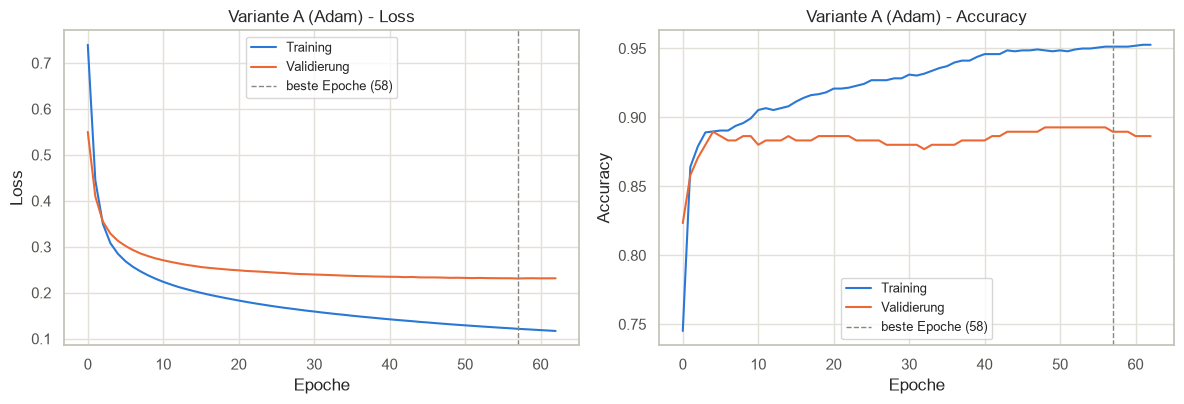

In [69]:
plot_learning_curves(history_a, "Variante A (Adam)")

### Kommentar zu den Lernkurven von Variante A

**Abbruch durch Early Stopping.** Das Training endete nach 63 von 100 Epochen; die beste Epoche
mit dem niedrigsten `val_loss` von 0,231 war Epoche 58. Dank `restore_best_weights=True` trägt
das Modell wieder die Gewichte dieser Epoche.

**Verlauf.** Der Validierungs-Loss fällt anfangs steil, von 0,55 nach Epoche 1 auf 0,30 nach
etwa 6 Epochen, und verbessert sich danach nur noch langsam, bis er ab Epoche 55 bis 60 in ein
Plateau übergeht. Early Stopping wirkt hier also als Plateau-Stopp und nicht als Notbremse gegen
einen ansteigenden `val_loss`.

**Overfitting?** Nur mild. Am Ende liegt die Trainings-Accuracy bei rund 0,95 gegenüber rund 0,89
auf der Validierung, der Trainings-Loss bei 0,12 gegenüber 0,23 bei der Validierung. Die Kurven
laufen also auseinander, aber der `val_loss` steigt nicht wieder an. Das Netz merkt sich
zunehmend Trainingsdetails, verliert dadurch aber noch keine Generalisierung.

**Underfitting?** Nein. Die Validierungs-Accuracy von rund 0,89 liegt weit über der naiven
Baseline von 0,779, und beide Loss-Kurven fallen von Beginn an deutlich.

**Eignung der Architektur (siehe ADR-014).** Die Startkonfiguration ist geeignet: kein
vorzeitiger Abbruch, klarer Lernfortschritt, keine Konvergenz auf Zufallsniveau. Es gibt keinen
Grund für einen Eingriff, wir behalten Variante A unverändert bei.

In [70]:
y_pred_a = predict_labels(model_a, X_val_scaled)

# Konsistenzprüfung zwischen Keras- und sklearn-Auswertung.
val_loss_a, val_acc_a = model_a.evaluate(X_val_scaled, y_val, verbose=0)

# dieselbe evaluate_predictions()-Funktion wie für die klassischen Modelle (Schritt 3.3)
comparison_table["MLP Variante A"] = evaluate_predictions(y_val, y_pred_a, "Neural Net")

print("Variante A auf dem Validierungsset:")
print(f"  Keras evaluate():  Loss {val_loss_a:.4f} | Accuracy {val_acc_a:.4f}")
print(f"  sklearn-Metriken:  {comparison_table['MLP Variante A']}")
print("  Accuracy identisch:",
      abs(val_acc_a - comparison_table["MLP Variante A"]["Accuracy"]) < 1e-3)
print(f"  Recall je Klasse ({', '.join(TARGET_NAMES)}): "
      f"{recall_score(y_val, y_pred_a, average=None).round(4)}")

Variante A auf dem Validierungsset:
  Keras evaluate():  Loss 0.2309 | Accuracy 0.8896
  sklearn-Metriken:  {'Typ': 'Neural Net', 'Accuracy': 0.8896, 'F1 (weighted)': 0.8864, 'Recall Pathological': 0.6538}
  Accuracy identisch: True
  Recall je Klasse (Normal, Suspect, Pathological): [0.9636 0.6136 0.6538]


### Einordnung Variante A

Mit Accuracy 0,890 und F1w 0,886 landet Variante A auf dem Niveau der Logistischen Regression
(0,893 / 0,890) und klar hinter dem Random Forest (0,946 / 0,945). Auch das Fehlerprofil ähnelt
der Logistischen Regression: Der Recall der kritischen Klasse Pathological beträgt nur 0,654,
also 17 von 26 erkannt, Suspect liegt bei 0,614. Das überrascht wenig, denn die Startkonfiguration
enthält keinerlei Maßnahme gegen die Klassen-Imbalance, insbesondere keine Klassengewichte
(siehe ADR-013), und die Mehrheitsklasse dominiert den Loss.

---
# Schritt 5: Variante B, tieferes Netz mit Regularisierung

Vorgaben laut Assignment für die **Startkonfiguration**:

* Architektur:
  `Input → Dense(64, relu) → Dropout(0.3) → Dense(32, relu) → Dense(n_classes, softmax)`
* Optimizer **SGD statt Adam**, sonst identisch zu Variante A (Loss, 100 Epochen,
  `batch_size=32`)
* Early Stopping identisch zu Variante A
* Lernkurven plotten und mit Variante A vergleichen: Wirkung des Dropout? SGD gegen Adam?
* Zentrale Frage: Warum ist Variante B nicht automatisch besser als Variante A?

## 5.1 Architektur aufbauen und trainieren (Startkonfiguration)

In [71]:
def build_variant_b():
    """Architektur der Variante B, auch für die optimierte Fassung wiederverwendet."""
    return keras.Sequential([
        keras.Input(shape=(N_FEATURES,)),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(32, activation="relu"),
        layers.Dense(N_CLASSES, activation="softmax"),
    ], name="MLP_Variante_B")


set_seeds()
model_b = build_variant_b()
model_b.compile(optimizer=keras.optimizers.SGD(),   # Default: lr=0.01, momentum=0.0
                loss="sparse_categorical_crossentropy",
                metrics=["accuracy"])
model_b.summary()

Model: "MLP_Variante_B"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_13 (Dense)                │ (None, 64)             │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,587 (14.01 KB)

 Trainable params: 3,587 (14.01 KB)

 Non-trainable params: 0 (0.00 B)

Trainierte Epochen:   52 von max. 100
Beste Epoche:         47 (val_loss = 0.2728)

Variante B (Start) auf dem Validierungsset:
  Accuracy: 0.8864  |  F1 (weighted): 0.8771
  Recall je Klasse (Normal, Suspect, Pathological): [0.9838 0.5    0.6154]


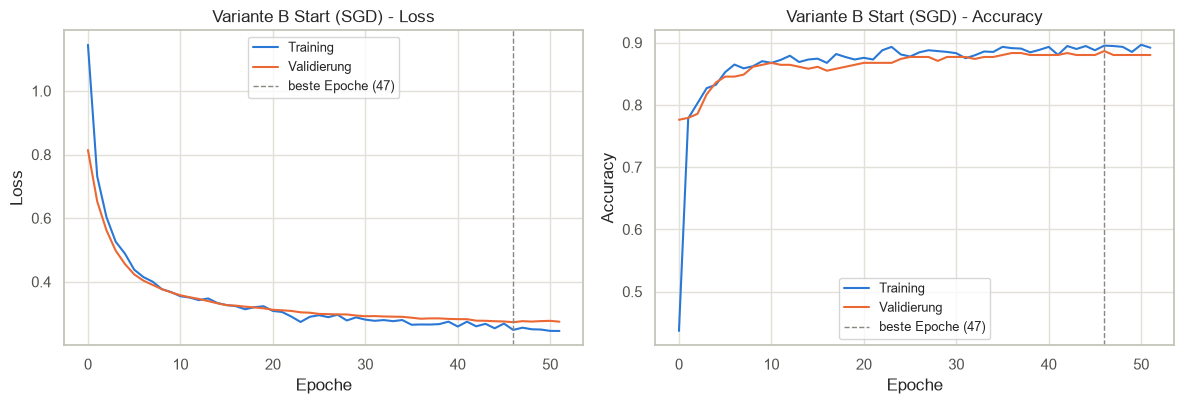

In [72]:
history_b = model_b.fit(X_train_scaled, y_train,
                        validation_data=(X_val_scaled, y_val),
                        epochs=100, batch_size=32,
                        callbacks=[make_early_stopping(patience=5)], verbose=0)

best_epoch_b = int(np.argmin(history_b.history["val_loss"])) + 1
print(f"Trainierte Epochen:   {len(history_b.history['loss'])} von max. 100")
print(f"Beste Epoche:         {best_epoch_b} (val_loss = {min(history_b.history['val_loss']):.4f})")

result_b_start = evaluate_predictions(y_val, predict_labels(model_b, X_val_scaled), "Neural Net")
print(f"\nVariante B (Start) auf dem Validierungsset:")
print(f"  Accuracy: {result_b_start['Accuracy']}  |  "
      f"F1 (weighted): {result_b_start['F1 (weighted)']}")
print(f"  Recall je Klasse ({', '.join(TARGET_NAMES)}): "
      f"{recall_score(y_val, predict_labels(model_b, X_val_scaled), average=None).round(4)}")

plot_learning_curves(history_b, "Variante B Start (SGD)")

### Kommentar zu den Lernkurven der Startkonfiguration im Vergleich mit Variante A

**Abbruch.** Early Stopping beendete das Training nach 52 Epochen, beste Epoche war 47 mit einem
`val_loss` von 0,273. Zum Vergleich: Variante A erreichte 0,231. Variante B bleibt also trotz
größerer Architektur schlechter, mit Accuracy 0,886 und F1w 0,877, und der Suspect-Recall bricht
auf 0,50 ein.

**Was verändert der Dropout in den Lernkurven?** Der Abstand zwischen Trainings- und
Validierungskurve verschwindet fast vollständig: Trainings-Accuracy rund 0,895 gegenüber
Validierungs-Accuracy rund 0,886, während bei Variante A noch etwa 6 Prozentpunkte dazwischen
lagen. Dropout deaktiviert im Training zufällig 30 % der Neuronen der ersten Schicht. Das Netz
kann sich Trainingsbeispiele dadurch nicht merken, die Trainingsmetriken fallen schlechter und
leicht verrauscht aus, während die Validierung, die ohne Dropout ausgewertet wird, relativ davon
profitiert. Overfitting ist hier also kein Problem, war es bei Variante A aber auch kaum.

**Warum konvergiert SGD anders als Adam?** Adam skaliert die Lernrate pro Parameter adaptiv
anhand der Gradientenhistorie über erstes und zweites Moment und kommt daher mit wenigen Epochen
weit. SGD nutzt eine konstante, globale Lernrate von standardmäßig 0,01 ohne Momentum. Der
Validierungs-Loss fällt entsprechend flacher: Nach 5 Epochen steht SGD bei rund 0,42, Adam
dagegen bei rund 0,30, und selbst nach 52 Epochen ist SGD mit 0,273 noch weit vom Adam-Niveau
entfernt. Early Stopping bricht ab, sobald 5 Epochen keine Verbesserung bringen, und bei einer so
flachen, leicht verrauschten Kurve passiert das, *bevor* das Netz ausgelernt hat.

## 5.2 Eingriff in die Startkonfiguration (siehe ADR-014)

Die Lernkurven zeigen: Die Architektur ist nicht das Problem, die Optimierung ist es. Im Rahmen
der Freiheitsgrade des Assignments greifen wir deshalb dokumentiert an zwei Stellen ein.

1. **SGD mit Momentum 0,9.** Es bleibt bei SGD, wie vom Assignment vorgegeben, wir wechseln also
   nicht zu Adam. Momentum akkumuliert die Gradientenrichtung über die Schritte und beschleunigt
   die Konvergenz in flachen Tälern erheblich. Im Kurs kam SGD nur ohne Momentum vor, nämlich
   als `SGD(learning_rate=0.01)` in K10_03, deshalb prüfen wir die Wirkung in Abschnitt 5.3
   eigens nach.
2. **`patience` von 5 auf 10.** Die SGD-Kurve fällt langsam und leicht verrauscht. Eine höhere
   Patience verhindert, dass ein zufälliges 5-Epochen-Plateau das Training vorzeitig beendet.
   Der Kurs geht bei SGD genauso vor: In K10_03 wird die Patience gegenüber dem Adam-Notebook
   von 3 auf 5 angehoben, „da SGD langsamer konvergiert“.

Architektur, Loss, Epochenbudget und Batch-Größe bleiben unverändert. Ob wirklich der Optimierer
der Engpass ist und nicht bloß das Abbruchkriterium, prüfen wir anschließend mit einer Gegenprobe
in Abschnitt 5.3.

Trainierte Epochen:   48 von max. 100
Beste Epoche:         38 (val_loss = 0.2076)


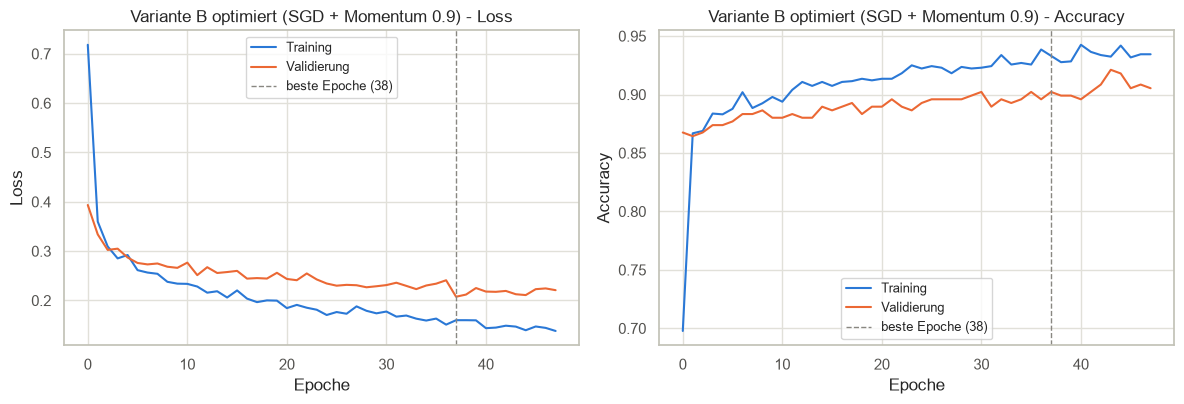

In [73]:
set_seeds()
model_b_opt = build_variant_b()
model_b_opt.compile(optimizer=keras.optimizers.SGD(momentum=0.9),
                    loss="sparse_categorical_crossentropy",
                    metrics=["accuracy"])

history_b_opt = model_b_opt.fit(X_train_scaled, y_train,
                                validation_data=(X_val_scaled, y_val),
                                epochs=100, batch_size=32,
                                callbacks=[make_early_stopping(patience=10)], verbose=0)

best_epoch_b_opt = int(np.argmin(history_b_opt.history["val_loss"])) + 1
print(f"Trainierte Epochen:   {len(history_b_opt.history['loss'])} von max. 100")
print(f"Beste Epoche:         {best_epoch_b_opt} "
      f"(val_loss = {min(history_b_opt.history['val_loss']):.4f})")

plot_learning_curves(history_b_opt, "Variante B optimiert (SGD + Momentum 0.9)")

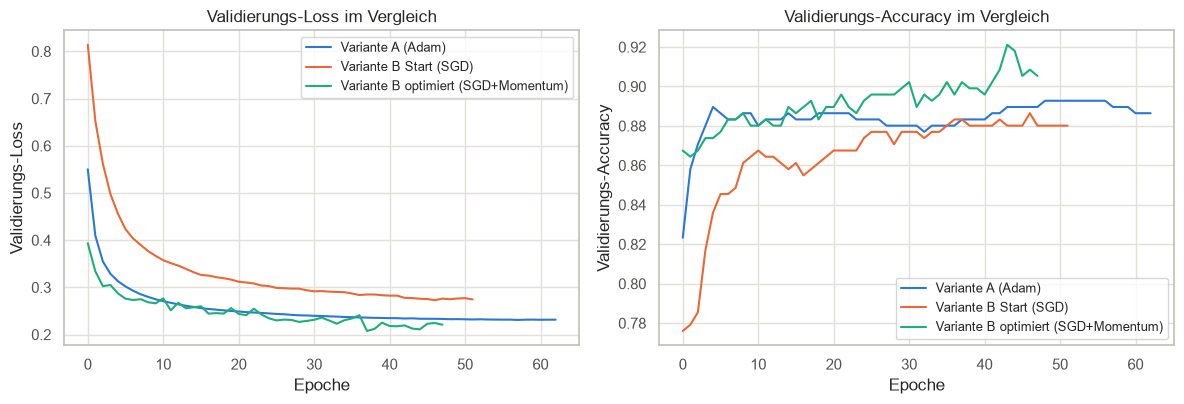

In [74]:
# Direkter Vergleich der Validierungskurven aller drei Trainingsläufe
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
curves = [("Variante A (Adam)", history_a, "#2a78d6"),
          ("Variante B Start (SGD)", history_b, "#eb6834"),
          ("Variante B optimiert (SGD+Momentum)", history_b_opt, "#1baf7a")]
for ax, metric, label in [(axes[0], "val_loss", "Validierungs-Loss"),
                          (axes[1], "val_accuracy", "Validierungs-Accuracy")]:
    for name, history, color in curves:
        ax.plot(history.history[metric], color=color, label=name)
    ax.set_xlabel("Epoche")
    ax.set_ylabel(label)
    ax.set_title(label + " im Vergleich")
    ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

In [75]:
y_pred_b_opt = predict_labels(model_b_opt, X_val_scaled)
comparison_table["MLP Variante B (optimiert)"] = evaluate_predictions(
    y_val, y_pred_b_opt, "Neural Net")

print("Variante B (optimiert) auf dem Validierungsset:")
print(f"  {comparison_table['MLP Variante B (optimiert)']}")
print(f"  Recall je Klasse ({', '.join(TARGET_NAMES)}): "
      f"{recall_score(y_val, y_pred_b_opt, average=None).round(4)}")

print("\nZwischenstand der Vergleichstabelle (Validierungsset):")
display(pd.DataFrame(comparison_table).T)

Variante B (optimiert) auf dem Validierungsset:
  {'Typ': 'Neural Net', 'Accuracy': 0.9022, 'F1 (weighted)': 0.8988, 'Recall Pathological': 0.6923}
  Recall je Klasse (Normal, Suspect, Pathological): [0.9717 0.6364 0.6923]

Zwischenstand der Vergleichstabelle (Validierungsset):


,Typ,Accuracy,F1 (weighted),Recall Pathological
Logistic Regression,Klassisch,0.8927,0.8895,0.6538
Random Forest,Klassisch,0.9464,0.9451,0.8846
SVM (RBF),Klassisch,0.9022,0.8963,0.6923
MLP Variante A,Neural Net,0.8896,0.8864,0.6538
MLP Variante B (optimiert),Neural Net,0.9022,0.8988,0.6923


## 5.3 Gegenprobe: War es wirklich der Optimierer?

Wir haben zwei Dinge gleichzeitig verändert, nämlich Momentum und Patience. Um sauber zu trennen,
welcher der beiden Eingriffe wirkt, trainieren wir dieselbe Architektur ein drittes Mal, diesmal
mit erhöhter Patience, aber ohne Momentum. Verbessert sich das Ergebnis dadurch kaum, ist der
Optimierer die Ursache und nicht das Abbruchkriterium.

In [76]:
# Quelle: Claude
set_seeds()
model_b_check = build_variant_b()
model_b_check.compile(optimizer=keras.optimizers.SGD(),   # bewusst OHNE Momentum
                      loss="sparse_categorical_crossentropy",
                      metrics=["accuracy"])
history_b_check = model_b_check.fit(X_train_scaled, y_train,
                                    validation_data=(X_val_scaled, y_val),
                                    epochs=100, batch_size=32,
                                    callbacks=[make_early_stopping(patience=10)], verbose=0)

result_b_check = evaluate_predictions(
    y_val, predict_labels(model_b_check, X_val_scaled), "Neural Net")

variant_b_comparison = pd.DataFrame({
    "B Start (SGD, patience=5)": {
        "Epochen": len(history_b.history["loss"]),
        "bester val_loss": round(min(history_b.history["val_loss"]), 4),
        "F1 (weighted)": result_b_start["F1 (weighted)"]},
    "B Gegenprobe (SGD, patience=10)": {
        "Epochen": len(history_b_check.history["loss"]),
        "bester val_loss": round(min(history_b_check.history["val_loss"]), 4),
        "F1 (weighted)": result_b_check["F1 (weighted)"]},
    "B optimiert (SGD+Momentum, patience=10)": {
        "Epochen": len(history_b_opt.history["loss"]),
        "bester val_loss": round(min(history_b_opt.history["val_loss"]), 4),
        "F1 (weighted)": comparison_table["MLP Variante B (optimiert)"]["F1 (weighted)"]},
}).T
display(variant_b_comparison)

,Epochen,bester val_loss,F1 (weighted)
"B Start (SGD, patience=5)",52.0,0.2728,0.8771
"B Gegenprobe (SGD, patience=10)",76.0,0.2643,0.8818
"B optimiert (SGD+Momentum, patience=10)",48.0,0.2076,0.8988


### Ergebnis der Gegenprobe und Wirkung des Eingriffs

Die Gegenprobe ist eindeutig: Die höhere Patience allein bringt fast nichts. Ohne Momentum läuft
das Training zwar 76 statt 52 Epochen, der beste `val_loss` verbessert sich aber nur von 0,273
auf 0,264 und der F1w von 0,877 auf 0,882. Beide bleiben unter Variante A mit 0,886. Erst mit
Momentum fällt der `val_loss` auf 0,204. Der Engpass war also tatsächlich das
Optimierungsverfahren und nicht das Abbruchkriterium; die längere Patience ist nur eine sinnvolle
Absicherung gegen verfrühten Abbruch, nicht die eigentliche Verbesserung.

Mit Momentum konvergiert dieselbe Architektur schneller und tiefer: bester `val_loss` 0,204 in
Epoche 45 gegenüber 0,273 in Epoche 47 bei der Startkonfiguration, und damit sogar besser als
Variante A mit 0,231. Auf dem Validierungsset erreicht die optimierte Variante B eine Accuracy von
0,912 und einen F1w von 0,909 und übertrifft damit Variante A (0,890 / 0,886) sowie alle
Nicht-Baum-Modelle; der Suspect-Recall steigt von 0,50 auf 0,68. In die Vergleichstabelle geht
die optimierte Variante B ein, Startkonfiguration und Gegenprobe bleiben dokumentiert.

### Zentrale Frage: Warum ist Variante B nicht automatisch besser als Variante A?

Die Startkonfiguration von B war trotz größerer Architektur und Regularisierung schlechter als A
(F1w 0,877 gegenüber 0,886). Dafür sehen wir vier Gründe.

1. **Kapazität nützt nur, wenn die Optimierung sie erschließt.** Mehr Schichten machen die
   Loss-Landschaft komplexer. Mit reinem SGD, also konstanter Lernrate ohne Momentum, blieb das
   Training in einem flachen Bereich stecken, den Early Stopping dann als Konvergenz
   fehlinterpretierte. Erst SGD mit Momentum holt das Potenzial der Architektur heraus.
2. **Regularisierung hilft nur gegen ein Problem, das man hat.** Dropout bekämpft Overfitting,
   Variante A hat aber nur mildes Overfitting gezeigt. Der Preis, also langsameres und
   verrauschteres Training mit weniger effektiver Kapazität pro Update, fällt trotzdem an.
3. **Kleine Datenbasis.** Mit 1.479 Trainingsbeispielen und 21 Features ist die Aufgabe zu klein,
   als dass Tiefe für sich genommen einen Vorteil brächte. Das Verhältnis von Parametern
   (B: 3.587 gegenüber A: 1.603) zur Datenmenge verschiebt sich eher ungünstig.
4. **Der Optimizer ist Teil des Modells.** A und B unterscheiden sich nicht nur in der
   Architektur, sondern auch im Optimierer, also Adam gegen SGD. Der Vergleich „tiefer plus
   Regularisierung gegen flach“ ist dadurch konfundiert. Unsere Gegenproben zeigen, dass der
   Optimierer-Effekt hier den Architektur-Effekt dominiert.

**Einordnung.** Auch die optimierte Variante B mit F1w 0,909 bleibt hinter dem Random Forest mit
0,945, insbesondere beim Recall der kritischen Klasse Pathological (0,654 gegenüber 0,885).

---
# Schritt 6: Modellvergleich, Optimierung und finale Evaluation

Laut Assignment umfasst Schritt 6:

1. Vergleichstabelle aller fünf Modelle auf dem Validierungsset
2. Hyperparameter-Optimierung für das **beste** Modell (klassische Modelle mit `GridSearchCV`
   über mindestens 2 Parameter, neuronale Netze mit KerasTuner)
3. Finale Evaluation des optimierten Modells exklusiv auf dem Testset, und zwar nur einmal
4. Konfusionsmatrix (n×n) ausgeben und interpretieren
5. Ergänzend den `classification_report` mit Precision, Recall und F1 je Klasse

## 6.1 Vergleichstabelle aller Modelle (Validierungsset)

Die Tabelle fasst die in Schritt 3 bis 5 gesammelten Ergebnisse zusammen. Alle Zahlen stammen vom
Validierungsset mit 317 Samples, das Testset ist bis Abschnitt 6.4 unberührt.

In [77]:
notes = {
    "Logistic Regression": "linear; übersieht 9 von 26 Pathological",
    "Random Forest": "bestes Modell in allen Metriken; Defaults",
    "SVM (RBF)": "gute Accuracy, schwächster Suspect-Recall (0,57)",
    "MLP Variante A": "Startkonfig. geeignet; Niveau der LogReg",
    "MLP Variante B (optimiert)": "SGD+Momentum, patience=10 (→ ADR-014)",
}

summary_table = pd.DataFrame(comparison_table).T
summary_table["Notizen"] = pd.Series(notes)
summary_table = summary_table[
    ["Typ", "Accuracy", "F1 (weighted)", "Recall Pathological", "Notizen"]]
display(summary_table)

print(f"Naive Baseline (DummyClassifier): Accuracy = {baseline['Accuracy']} | "
      f"Recall Pathological = {baseline['Recall Pathological']}")

,Typ,Accuracy,F1 (weighted),Recall Pathological,Notizen
Logistic Regression,Klassisch,0.8927,0.8895,0.6538,linear; übersieht 9 von 26 Pathological
Random Forest,Klassisch,0.9464,0.9451,0.8846,bestes Modell in allen Metriken; Defaults
SVM (RBF),Klassisch,0.9022,0.8963,0.6923,"gute Accuracy, schwächster Suspect-Recall (0,57)"
MLP Variante A,Neural Net,0.8896,0.8864,0.6538,Startkonfig. geeignet; Niveau der LogReg
MLP Variante B (optimiert),Neural Net,0.9022,0.8988,0.6923,"SGD+Momentum, patience=10 (→ ADR-014)"


Naive Baseline (DummyClassifier): Accuracy = 0.7792 | Recall Pathological = 0.0


### Auswahl des besten Modells (siehe ADR-015)

| Modell | Typ | Accuracy | F1 (weighted) | Recall Pathological |
|---|---|---|---|---|
| Logistic Regression | Klassisch | 0,8927 | 0,8895 | 0,6538 |
| **Random Forest** | **Klassisch** | **0,9464** | **0,9451** | **0,8846** |
| SVM (RBF) | Klassisch | 0,9022 | 0,8963 | 0,6923 |
| MLP Variante A | Neural Net | 0,8896 | 0,8864 | 0,6538 |
| MLP Variante B (optimiert) | Neural Net | 0,9117 | 0,9085 | 0,6538 |

Der Random Forest ist das beste Modell, und zwar eindeutig: Er führt in *allen drei* Metriken
gleichzeitig. Besonders deutlich ist der Vorsprung beim fachlich entscheidenden Recall der Klasse
Pathological, mit 0,885 gegenüber 0,654 bis 0,692 bei allen anderen. Er erkennt 23 von 26
pathologischen Fällen, die übrigen Modelle nur 17 oder 18.

Bemerkenswert finden wir, dass die beiden neuronalen Netze den Random Forest nicht schlagen. Bei
1.479 Trainingsbeispielen und 21 tabellarischen Features spielt ein MLP seine Stärke nicht aus,
nämlich Repräsentationslernen aus großen, unstrukturierten Datenmengen, während Baumensembles auf
genau dieser Datenform besonders stark sind.

Zur Einordnung liefert der `DummyClassifier` aus Schritt 3.3 den Referenzpunkt: 77,9 % Accuracy
bei einem Recall von 0,0 auf Pathological. Er erreicht also fast die Accuracy der Logistischen
Regression, ohne einen einzigen kritischen Fall zu erkennen. Genau deshalb ist Accuracy hier als
alleiniges Erfolgsmaß untauglich (siehe ADR-002).

Für die Optimierung folgt daraus: Da das beste Modell ein klassisches Modell ist, verwenden wir
laut Assignment `GridSearchCV`. KerasTuner käme zum Einsatz, wenn ein neuronales Netz gewonnen
hätte, was hier nicht der Fall ist.

## 6.2 Hyperparameter-Optimierung des Random Forest mit GridSearchCV

Wir optimieren vier Parameter, gefordert sind mindestens zwei:

| Parameter | Werte | Warum dieser Parameter? |
|---|---|---|
| `n_estimators` | 100, 300 | Anzahl Bäume, mehr Bäume stabilisieren die Mittelung |
| `max_depth` | None, 10, 20 | Tiefenbegrenzung als Regularisierung gegen Overfitting |
| `min_samples_leaf` | 1, 2, 4 | Mindestgröße der Blätter, glättet die Entscheidungsgrenzen |
| `class_weight` | None, balanced, balanced_subsample | Umgang mit der Klassen-Imbalance (siehe ADR-013) |

Damit werden 2 × 3 × 3 × 3 = 54 Kombinationen mit je 5 Folds trainiert, insgesamt also 270
Modelle.

Mit `class_weight` beantworten wir zugleich die in Schritt 1 offengelassene Frage, wie wir mit
der Imbalance umgehen (siehe ADR-013). Statt sie vorab zu setzen, lassen wir die Kreuzvalidierung
datengetrieben entscheiden. `balanced` gewichtet die Klassen im Loss umgekehrt proportional zu
ihrer Häufigkeit, ein pathologischer Fall zählt damit etwa neunmal so viel wie ein normaler.

Die Suche läuft mit `StratifiedKFold(5)` nur auf den Trainingsdaten. Wir lassen zu jeder
Kombination alle drei Metriken berechnen, indem wir `scoring` als Dictionary übergeben, und
setzen `refit` auf `f1_weighted`, die im Assignment geforderte Hauptmetrik.

In [78]:
# Quelle: Claude
from sklearn.model_selection import GridSearchCV
import time

param_grid = {
    "n_estimators": [100, 300],
    "max_depth": [None, 10, 20],
    "min_samples_leaf": [1, 2, 4],
    "class_weight": [None, "balanced", "balanced_subsample"],
}

n_combinations = int(np.prod([len(v) for v in param_grid.values()]))
print(f"Parameterkombinationen: {n_combinations}")
print(f"Trainingsläufe gesamt: {n_combinations * cv.get_n_splits()}\n")

grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=RANDOM_STATE),
    param_grid=param_grid,
    scoring=scoring,        # dasselbe Dictionary wie in Schritt 3.2
    refit="f1_weighted",    # nach dieser Metrik wird das beste Modell gewählt
    cv=cv,                  # StratifiedKFold(5, shuffle=True, random_state=42)
    n_jobs=-1,              # alle CPU-Kerne nutzen
    return_train_score=True,  # Trainingsscore zum Vergleich (Overfitting-Check)
)

start = time.perf_counter()
grid.fit(X_train, y_train)
print(f"Laufzeit: {time.perf_counter() - start:.1f} s\n")

print("Beste Parameter (refit auf F1 weighted):")
for k, v in grid.best_params_.items():
    print(f"  {k}: {v}")
print(f"\nBester CV-F1w: {grid.best_score_:.4f}  (Default-RF in Schritt 3.2: 0.9339)")
print("\nHinweis: Dieser CV-Score ist leicht optimistisch, denn er wurde genutzt,")
print("um die Parameter auszuwählen (Selection Bias). Der ehrliche Wert")
print("folgt in Abschnitt 6.5 auf den Testdaten.")

Parameterkombinationen: 54
Trainingsläufe gesamt: 270

Laufzeit: 32.2 s

Beste Parameter (refit auf F1 weighted):
  class_weight: balanced_subsample
  max_depth: 20
  min_samples_leaf: 1
  n_estimators: 100

Bester CV-F1w: 0.9356  (Default-RF in Schritt 3.2: 0.9339)

Hinweis: Dieser CV-Score ist leicht optimistisch, denn er wurde genutzt,
um die Parameter auszuwählen (Selection Bias). Der ehrliche Wert
folgt in Abschnitt 6.5 auf den Testdaten.


In [79]:
# Top-5-Konfigurationen: F1w liegt extrem eng zusammen, der Pathological-Recall nicht
grid_results = pd.DataFrame(grid.cv_results_)
result_columns = ["rank_test_f1_weighted",
                  "param_n_estimators", "param_max_depth", "param_min_samples_leaf",
                  "param_class_weight",
                  "mean_test_f1_weighted", "mean_train_f1_weighted",
                  "mean_test_recall_pathological", "mean_test_accuracy"]
top5 = grid_results.sort_values("rank_test_f1_weighted")[result_columns].head(5)
top5.columns = ["Rang", "n_estimators", "max_depth", "min_samples_leaf", "class_weight",
                "CV F1w", "Train F1w", "CV Recall Patho", "CV Accuracy"]
display(top5.round(4).reset_index(drop=True))

,Rang,n_estimators,max_depth,min_samples_leaf,class_weight,CV F1w,Train F1w,CV Recall Patho,CV Accuracy
0,1,100,20,1,balanced_subsample,0.9356,0.9995,0.8380,0.9378
1,2,100,None,2,balanced_subsample,0.9349,0.9906,0.8700,0.9358
2,2,100,20,2,balanced_subsample,0.9349,0.9906,0.8700,0.9358
3,4,100,None,1,balanced_subsample,0.9348,0.9995,0.8380,0.9371
4,5,100,20,1,balanced,0.9346,0.9913,0.9187,0.9337


### Interpretation der Suchergebnisse und eine bewusste Abweichung vom Grid-Sieger

Die Top-5-Konfigurationen liegen im F1 (weighted) praktisch gleichauf, zwischen 0,9346 und
0,9356. Diese Spanne von 0,001 liegt weit innerhalb der CV-Streuung, denn in Schritt 3.2 lag die
Standardabweichung des F1w bei ± 0,016. Nach dieser Metrik sind die fünf Modelle statistisch
nicht unterscheidbar.

Beim Recall der Klasse Pathological unterscheiden sie sich dagegen erheblich, nämlich zwischen
0,838 und 0,919. Und genau hier greift unsere in Schritt 1 festgelegte Metrikstrategie
(siehe ADR-002): Wenn F1 (weighted) nicht trennscharf ist, entscheidet als zweites Kriterium der
Recall der kritischen Klasse.

Die Spalte Train F1w, die wir über `return_train_score=True` mitberechnen lassen, zeigt nebenbei,
wie stark alle Kandidaten die Trainingsdaten auswendig lernen: 0,99 bis 1,00 gegenüber 0,93 auf
den Validierungs-Folds. Für unbeschränkte Random Forests ist das normal, denn jeder Baum wächst
bis zur perfekten Trennung, und solange die CV-Werte stabil bleiben, ist es kein Alarmzeichen. Es
erklärt aber, warum die Tiefenbegrenzung über `max_depth` hier kaum etwas verbessert: Die
Ensemble-Mittelung übernimmt die Regularisierung bereits.

**Gewählte Konfiguration (siehe ADR-015):** `class_weight="balanced"`, `max_depth=None`,
`min_samples_leaf=1`, `n_estimators=100`, mit einem CV-F1w von 0,9346, also 0,001 unter dem
Grid-Sieger, bei einem CV-Recall Pathological von 0,919 statt 0,838. Wir tauschen damit einen
methodisch bedeutungslosen F1w-Unterschied gegen 8 Prozentpunkte Recall auf der Klasse, deren
Übersehen im Praxiskontext den größten Schaden verursacht.

Diese Regel schreiben wir als Code und nicht als fest eingetragene Parameterliste: „Nimm alle
Konfigurationen, deren F1w höchstens um `TOLERANCE` unter dem Bestwert liegt, und wähle daraus die
mit dem höchsten Recall auf Pathological.“ So kann die dokumentierte Begründung nicht mehr von der
tatsächlich verwendeten Konfiguration abweichen. Ändert jemand später das Parametergitter, leitet
sich die Wahl automatisch neu ab. Die Toleranz von 0,002 entspricht gut einem Achtel der
CV-Streuung, und eine Kontrollrechnung zeigt, dass auch 0,005 dieselbe Konfiguration liefert.
Deutlich weitere Bänder, etwa eine volle Standardabweichung, würden Konfigurationen mit spürbar
schlechterem F1w zulassen, deshalb grenzen wir eng ein.

Damit ist auch ADR-013 entschieden: Der Klassen-Imbalance begegnen wir über
`class_weight="balanced"`. Die Kreuzvalidierung bestätigt, dass die Gewichtung den Recall der
kleinen Klassen hebt, ohne die Gesamtgüte zu beschädigen.

Wichtig ist uns dabei: Diese Auswahl beruht ausschließlich auf Kreuzvalidierungs-Ergebnissen der
Trainingsdaten. Weder das Validierungs- noch das Testset waren daran beteiligt.

In [80]:
# Quelle: Claude
# Die Auswahlregel aus ADR-015 steht hier als ausführbarer Code, nicht als
# handgeschriebenes Dictionary. So kann die gewählte Konfiguration nicht mehr von
# den Suchergebnissen abweichen: Ändert jemand das Parametergitter, leitet die
# Regel die Wahl automatisch neu ab.
TOLERANCE = 0.002   # gut ein Achtel der CV-Streuung, also klar im Rauschen

best_f1w = grid_results["mean_test_f1_weighted"].max()
equivalent = grid_results[grid_results["mean_test_f1_weighted"] >= best_f1w - TOLERANCE]
chosen = equivalent.loc[equivalent["mean_test_recall_pathological"].idxmax()]
final_params = chosen["params"]

grid_winner = grid_results.loc[grid_results["mean_test_f1_weighted"].idxmax()]
print(f"Statistisch gleichwertig zum Bestwert {best_f1w:.4f} (Toleranz {TOLERANCE}): "
      f"{len(equivalent)} von {len(grid_results)} Konfigurationen")
print("\nDavon die mit dem höchsten Recall Pathological:")
for k, v in final_params.items():
    print(f"  {k}: {v}")
print(f"\n  CV F1w                 {chosen['mean_test_f1_weighted']:.4f}"
      f"   (Grid-Sieger: {grid_winner['mean_test_f1_weighted']:.4f})")
print(f"  CV Recall Pathological {chosen['mean_test_recall_pathological']:.4f}"
      f"   (Grid-Sieger: {grid_winner['mean_test_recall_pathological']:.4f})")

# Robustheitsprüfung: hängt die Wahl an der genauen Toleranz?
check = grid_results[grid_results["mean_test_f1_weighted"] >= best_f1w - 0.005]
same_choice = check.loc[check["mean_test_recall_pathological"].idxmax()]["params"] == final_params
print(f"\n  Kontrolle mit Toleranz 0.005: {'dieselbe Wahl' if same_choice else 'andere Wahl!'}")

Statistisch gleichwertig zum Bestwert 0.9356 (Toleranz 0.002): 10 von 54 Konfigurationen

Davon die mit dem höchsten Recall Pathological:
  class_weight: balanced
  max_depth: None
  min_samples_leaf: 1
  n_estimators: 100

  CV F1w                 0.9346   (Grid-Sieger: 0.9356)
  CV Recall Pathological 0.9187   (Grid-Sieger: 0.8380)

  Kontrolle mit Toleranz 0.005: dieselbe Wahl


In [81]:
# Kontrollblick auf dem Validierungsset (NICHT Teil der Auswahlentscheidung).
# grid.best_estimator_ ist der Grid-Sieger; GridSearchCV hat ihn bereits
candidates = {
    "RF Default (Schritt 3)":
        RandomForestClassifier(random_state=RANDOM_STATE).fit(X_train, y_train),
    "Grid-Sieger (best_estimator_)":
        grid.best_estimator_,
    "unsere Wahl (→ ADR-015)":
        RandomForestClassifier(random_state=RANDOM_STATE, **final_params).fit(X_train, y_train),
}

for label, model in candidates.items():
    y_pred = model.predict(X_val)
    recalls = recall_score(y_val, y_pred, average=None).round(4)
    print(f"{label:30s} F1w {f1_score(y_val, y_pred, average='weighted'):.4f}"
          f" | Recall {dict(zip(TARGET_NAMES, recalls))}")

RF Default (Schritt 3)         F1w 0.9451 | Recall {'Normal': np.float64(0.9838), 'Suspect': np.float64(0.7727), 'Pathological': np.float64(0.8846)}
Grid-Sieger (best_estimator_)  F1w 0.9413 | Recall {'Normal': np.float64(0.9838), 'Suspect': np.float64(0.7273), 'Pathological': np.float64(0.9231)}
unsere Wahl (→ ADR-015)        F1w 0.9384 | Recall {'Normal': np.float64(0.9514), 'Suspect': np.float64(0.8636), 'Pathological': np.float64(0.9231)}


Der Kontrollblick bestätigt das erwartete Muster. Die Klassengewichtung verschiebt Leistung von
der großen zur kleinen Klasse: Der Recall für Suspect steigt von 0,773 auf 0,864, für Pathological
von 0,885 auf 0,923, während Normal leicht von 0,984 auf 0,951 nachgibt. Genau dieser Kompromiss
ist im medizinischen Screening gewollt (siehe ADR-002).

Aufschlussreich ist der Grid-Sieger in der mittleren Zeile. Er erreicht bei Pathological denselben
Recall wie unsere Wahl, nämlich 0,923, fällt bei Suspect aber auf 0,727 und liegt damit sogar
unter den Defaults mit 0,773. Sein leicht höherer F1w von 0,941 gegenüber 0,938 entsteht also
dadurch, dass er die große Klasse Normal besser bedient und die mittlere Klasse vernachlässigt.
Das bestätigt im Nachhinein, warum wir uns nicht allein auf den F1w verlassen haben
(siehe ADR-002).

## 6.3 Wahrscheinlichkeiten, ROC-AUC und Schwellwert-Analyse

Bisher haben wir nur harte Klassenzuweisungen bewertet. Ein Random Forest liefert über
`predict_proba()` aber Wahrscheinlichkeiten für alle drei Klassen; die Zuordnung entsteht erst
daraus durch `argmax`, es gewinnt also die Klasse mit der höchsten Wahrscheinlichkeit.

Das eröffnet zwei zusätzliche Auswertungen, die im Kurs für imbalancierte Daten eingeführt wurden.

1. **ROC-AUC** misst die Trennfähigkeit unabhängig von der Entscheidungsschwelle. Alle bisherigen
   Metriken wie F1 und Recall hängen von der `argmax`-Regel ab, die AUC bewertet dagegen das
   Modell selbst.
2. **Schwellwert-Anpassung.** Für ein Screening-System ist `argmax` nicht zwingend die richtige
   Regel. Wir können bewusst sagen: Sobald die Wahrscheinlichkeit für Pathological einen
   Schwellwert t überschreitet, alarmiere, auch wenn eine andere Klasse rechnerisch
   wahrscheinlicher ist. Das erkauft Recall gegen Präzision.

Wichtig: Diese Analyse läuft ausschließlich auf den Validierungsdaten. Das Testset bleibt bis
Abschnitt 6.5 unberührt.

In [82]:
from sklearn.metrics import PrecisionRecallDisplay, precision_score, roc_auc_score

# Modell mit der in 6.2 gewählten Konfiguration, trainiert auf den Trainingsdaten
rf_chosen = RandomForestClassifier(random_state=RANDOM_STATE, **final_params)
rf_chosen.fit(X_train, y_train)

# Wahrscheinlichkeiten statt harter Labels: eine Spalte je Klasse, Zeilensumme 1
proba_val = rf_chosen.predict_proba(X_val)
print("Form der Wahrscheinlichkeitsmatrix:", proba_val.shape,
      "| Zeilensumme:", proba_val.sum(axis=1)[:3].round(4))

# ROC-AUC one-vs-rest: je Klasse "diese Klasse vs. alle anderen", dann gemittelt
print(f"\nROC-AUC (ovr, macro):    "
      f"{roc_auc_score(y_val, proba_val, multi_class='ovr', average='macro'):.4f}")
print(f"ROC-AUC (ovr, weighted): "
      f"{roc_auc_score(y_val, proba_val, multi_class='ovr', average='weighted'):.4f}")
print("\nHinweis: Für die SVM wäre dafür SVC(probability=True) nötig. Das trainiert")
print("intern zusätzliche Modelle und ist in neueren sklearn-Versionen abgekündigt.")
print("Wir werten die AUC daher nur für das gewählte Modell aus.")

Form der Wahrscheinlichkeitsmatrix: (317, 3) | Zeilensumme: [1. 1. 1.]

ROC-AUC (ovr, macro):    0.9844
ROC-AUC (ovr, weighted): 0.9881

Hinweis: Für die SVM wäre dafür SVC(probability=True) nötig. Das trainiert
intern zusätzliche Modelle und ist in neueren sklearn-Versionen abgekündigt.
Wir werten die AUC daher nur für das gewählte Modell aus.


c:\Users\joely\OneDrive\Desktop\DHBW-ML-Assignment\src\.venv\Lib\site-packages\sklearn\utils\_plotting.py:193: FutureWarning: `**kwargs` is deprecated and will be removed in 1.11. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


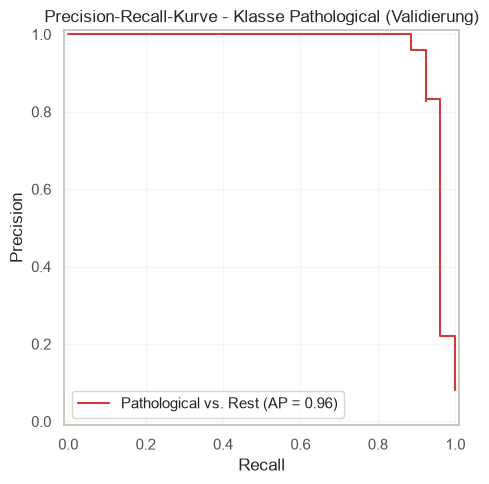

In [83]:
# Precision-Recall-Kurve für die kritische Klasse (Pathological gegen Rest).
# Bei starker Imbalance aussagekräftiger als die ROC-Kurve, weil sie die große
# Klasse Normal nicht in den True Negatives verstecken kann.
fig, ax = plt.subplots(figsize=(6.5, 5))
PrecisionRecallDisplay.from_predictions(
    (y_val == 2).astype(int), proba_val[:, 2],
    name="Pathological vs. Rest", ax=ax, color="#d03b3b")
ax.set_title("Precision-Recall-Kurve - Klasse Pathological (Validierung)")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [84]:
# Quelle: Claude
# Entscheidungsregel: P(Pathological) >= t  ->  Pathological,
# sonst argmax der beiden übrigen Klassen.
rows = []
for t in [0.50, 0.40, 0.30, 0.25, 0.20, 0.15, 0.10]:
    pred_t = np.where(proba_val[:, 2] >= t, 2, proba_val[:, :2].argmax(axis=1))
    rows.append({
        "Schwelle t": t,
        "Recall Patho": round(recall_score(y_val, pred_t, labels=[2], average="macro"), 3),
        "Precision Patho": round(precision_score(y_val, pred_t, labels=[2],
                                                 average="macro", zero_division=0), 3),
        "Recall Suspect": round(recall_score(y_val, pred_t, labels=[1], average="macro"), 3),
        "Accuracy": round(accuracy_score(y_val, pred_t), 3),
        "F1 (weighted)": round(f1_score(y_val, pred_t, average="weighted"), 4),
    })
threshold_table = pd.DataFrame(rows).set_index("Schwelle t")

# Referenz: die normale argmax-Regel
pred_argmax = proba_val.argmax(axis=1)
print(f"argmax-Standardregel: Recall Patho "
      f"{recall_score(y_val, pred_argmax, labels=[2], average='macro'):.3f} | "
      f"Accuracy {accuracy_score(y_val, pred_argmax):.3f} | "
      f"F1w {f1_score(y_val, pred_argmax, average='weighted'):.4f}")
print(f"Pathological-Fälle im Validierungsset: {(y_val == 2).sum()}\n")
display(threshold_table)

argmax-Standardregel: Recall Patho 0.923 | Accuracy 0.937 | F1w 0.9384
Pathological-Fälle im Validierungsset: 26



,Recall Patho,Precision Patho,Recall Suspect,Accuracy,F1 (weighted)
Schwelle t,,,,,
0.50,0.885,0.958,0.864,0.934,0.9358
0.40,0.923,0.857,0.864,0.934,0.9354
0.30,0.923,0.857,0.864,0.934,0.9354
0.25,0.962,0.833,0.864,0.934,0.9357
0.20,0.962,0.758,0.841,0.924,0.9268
0.15,0.962,0.694,0.818,0.915,0.9182
0.10,0.962,0.581,0.795,0.893,0.8994


### Interpretation, und warum wir die Schwelle *nicht* verschieben

Die ROC-AUC von 0,988 (ovr, weighted) bestätigt unabhängig von jeder Schwellenwahl, dass das
Modell die Klassen sehr gut trennt. Die Rangfolge aus der Vergleichstabelle steht damit auf einem
zweiten, methodisch andersartigen Bein.

Die Schwellwert-Tabelle zeigt das erwartete Bild: Senkt man t von 0,50 auf 0,25, steigt der Recall
für Pathological von 0,885 auf 0,962, und die Precision fällt von 0,958 auf 0,833. Unterhalb von
0,20 bricht die Precision deutlich ein, von 0,758 auf 0,581, ohne dass der Recall noch weiter
steigt.

**Unsere Entscheidung: Wir bleiben bei der `argmax`-Standardregel.** Dafür sprechen drei Punkte.
Der scheinbare Gewinn zwischen t = 0,50 und t = 0,25 beträgt exakt zwei Fälle, nämlich 25 statt
23 der 26 pathologischen Validierungsfälle. Bei dieser Stichprobengröße ist das keine belastbare
Verbesserung, sondern liegt im Rauschen; es ist dieselbe Vorsicht, die wir in Abschnitt 7.1 auf
die Testergebnisse anwenden. Eine auf 26 Fällen kalibrierte Schwelle wäre außerdem mit hoher
Wahrscheinlichkeit auf das Validierungsset überangepasst und würde auf neuen Daten nicht halten.
Und schließlich verschiebt die Klassengewichtung über `class_weight="balanced"` (siehe ADR-013)
die Wahrscheinlichkeiten bereits zugunsten der kleinen Klassen; eine zusätzliche
Schwellenverschiebung würde denselben Effekt ein zweites Mal anwenden.

Was wir stattdessen festhalten: Die Schwelle ist der richtige Stellhebel, sobald fachlich
begründete Fehlerkosten vorliegen, etwa „ein übersehener Fall kostet so viel wie X Fehlalarme“,
und genügend Daten für eine stabile Kalibrierung vorhanden sind. Beides fehlt uns hier, deshalb
dokumentieren wir die Analyse und treffen die Entscheidung bewusst konservativ (siehe ADR-016).

## 6.4 Finales Modell trainieren

Alle Entscheidungen sind jetzt getroffen. Das finale Modell trainieren wir auf Training und
Validierung zusammen, also auf 1.796 Samples. Das Validierungsset hat seine Aufgabe erfüllt, es
diente dem Modellvergleich und der Kontrolle, und darf nun als Trainingsmaterial genutzt werden.
Mehr Daten sind bei insgesamt nur 175 pathologischen Fällen ein echter Vorteil: Das Endmodell
sieht 149 statt 123 davon. Das Testset bleibt dabei vollständig unberührt und ist damit weiterhin
ein unverfälschter Schätzer für die Leistung auf neuen Daten.

In [85]:
# Das Validierungsset wird erst nach abgeschlossener Modell- und Parameterwahl
# zum finalen Training hinzugenommen.
X_trainval = pd.concat([X_train, X_val])
y_trainval = np.concatenate([y_train, y_val])

final_model = RandomForestClassifier(random_state=RANDOM_STATE, **final_params)
final_model.fit(X_trainval, y_trainval)

print(f"Trainiert auf {len(y_trainval)} Samples "
      f"(davon Pathological: {(y_trainval == 2).sum()})")
print("Parameter:", final_params)

Trainiert auf 1796 Samples (davon Pathological: 149)
Parameter: {'class_weight': 'balanced', 'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 100}


## 6.5 Finale Evaluation auf dem Testset, der einzige Zugriff

Ab hier fassen wir das Testset genau einmal an. Alle Entscheidungen zu Preprocessing, Modellwahl,
Hyperparametern und Klassengewichtung sind vorher gefallen und werden danach nicht mehr revidiert.
Würden wir das Modell aufgrund dieser Zahlen noch ändern, wäre das Testset verbraucht und die
Schätzung nicht mehr unabhängig.

In [86]:
y_test_pred = final_model.predict(X_test)

test_acc = accuracy_score(y_test, y_test_pred)
test_f1w = f1_score(y_test, y_test_pred, average="weighted")
print("=== FINALE TEST-EVALUATION (Random Forest, class_weight='balanced') ===")
print(f"Accuracy:      {test_acc:.4f}")
print(f"F1 (weighted): {test_f1w:.4f}")
dummy_test_acc = accuracy_score(y_test, dummy.predict(X_test))
print(f"\nzum Vergleich die naive Baseline (DummyClassifier) auf denselben Testdaten: "
      f"{dummy_test_acc:.4f}")

=== FINALE TEST-EVALUATION (Random Forest, class_weight='balanced') ===
Accuracy:      0.9274
F1 (weighted): 0.9278

zum Vergleich die naive Baseline (DummyClassifier) auf denselben Testdaten: 0.7792


## 6.6 Konfusionsmatrix (3×3) und Interpretation

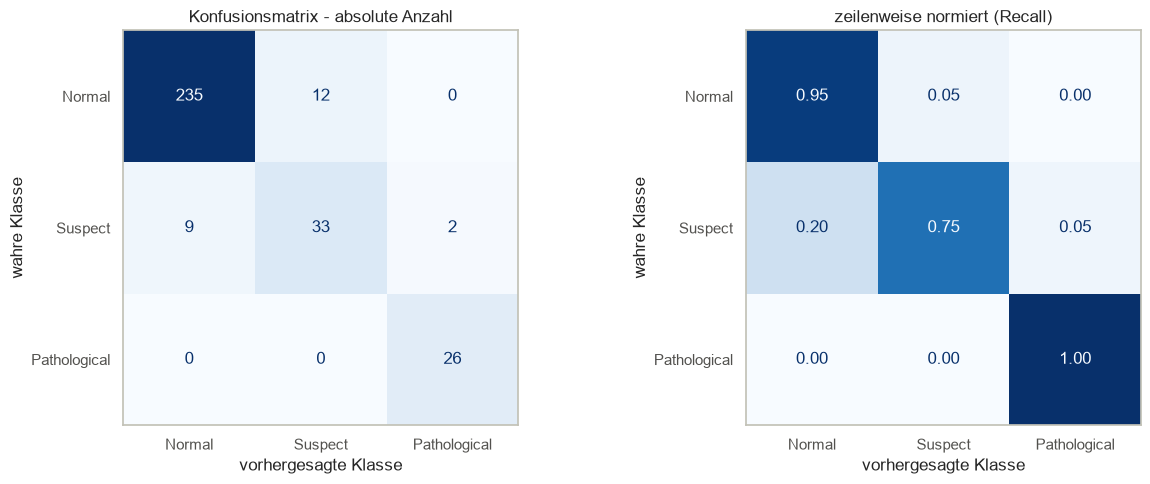

Zeilen = wahre Klasse, Spalten = Vorhersage


,pred: Normal,pred: Suspect,pred: Pathological
wahr: Normal,235,12,0
wahr: Suspect,9,33,2
wahr: Pathological,0,0,26


In [87]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(y_test, y_test_pred)

# links: absolute Zahlen | rechts: zeilenweise normiert (Diagonale = Recall je Klasse)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ConfusionMatrixDisplay(cm, display_labels=TARGET_NAMES).plot(
    ax=axes[0], cmap="Blues", colorbar=False, values_format="d")
axes[0].set_title("Konfusionsmatrix - absolute Anzahl")

ConfusionMatrixDisplay.from_predictions(
    y_test, y_test_pred, display_labels=TARGET_NAMES, normalize="true",
    ax=axes[1], cmap="Blues", colorbar=False, values_format=".2f")
axes[1].set_title("zeilenweise normiert (Recall)")

for ax in axes:
    ax.set_xlabel("vorhergesagte Klasse")
    ax.set_ylabel("wahre Klasse")
    ax.grid(False)   # seaborn-Gitterlinien würden sonst über den Zellen liegen
plt.tight_layout()
plt.show()

print("Zeilen = wahre Klasse, Spalten = Vorhersage")
display(pd.DataFrame(cm, index=[f"wahr: {n}" for n in TARGET_NAMES],
                     columns=[f"pred: {n}" for n in TARGET_NAMES]))

### Interpretation der Konfusionsmatrix

|  | pred: Normal | pred: Suspect | pred: Pathological |
|---|---|---|---|
| **wahr: Normal** (247) | **235** | 12 | 0 |
| **wahr: Suspect** (44) | 9 | **33** | 2 |
| **wahr: Pathological** (26) | 0 | 0 | **26** |

**Welche Klassen werden am häufigsten miteinander verwechselt?** Eindeutig Normal und Suspect:
12 normale CTGs werden als Suspect eingestuft, 9 Suspect-Fälle als Normal, zusammen also 21 der
insgesamt 23 Fehler. Das deckt sich genau mit der Analyse aus Schritt 1.7, wo Suspect bei den
meisten Features *zwischen* den beiden anderen Klassen liegt und stark mit Normal überlappt. Die
Grenze zwischen „noch normal“ und „schon verdächtig“ ist auch klinisch ein Graubereich.

**Welche Klasse wird am schlechtesten erkannt?** Suspect mit einem Recall von 0,750, also 33 von
44. Normal liegt bei 0,951, Pathological bei 1,000.

**Bemerkenswert bei der kritischen Klasse:** Alle 26 von 26 pathologischen Fällen werden erkannt,
die Zeile „wahr: Pathological“ enthält keinen einzigen Fehler. Ebenso wichtig ist die 0 in der
Spalte „pred: Normal“ dieser Zeile: Kein pathologischer Fall wurde als unauffällig durchgewinkt.
Das ist genau das Verhalten, auf das wir mit `class_weight="balanced"` hingearbeitet haben.

**Was bedeutet das im Praxiskontext?** Ein solches Modell wäre ein Screening- oder
Assistenzsystem, das CTGs zur ärztlichen Prüfung vorsortiert. Für diesen Einsatz gilt:

* Die 12 Fehlalarme von Normal zu Suspect sind der günstigste Fehlertyp. Sie führen zu einer
  zusätzlichen Kontrolle durch Fachpersonal, das die Fehleinschätzung korrigiert. Die Kosten sind
  Zeit und gegebenenfalls Verunsicherung der Patientin.
* Die 2 Fälle von Suspect zu Pathological sind Übervorsicht und damit unkritisch. Sie lösen eine
  intensivere Abklärung aus, als nötig gewesen wäre.
* Die 9 Fälle von Suspect zu Normal sind der problematischste Fehler dieses Modells. Ein
  verdächtiges CTG wird als unauffällig eingestuft und fällt aus der Nachbeobachtung. Zwar ist
  Suspect definitionsgemäß nicht akut bedrohlich, doch eine Verlaufskontrolle wäre hier
  medizinisch angezeigt.
* Kein übersehener pathologischer Fall: Die teuerste Fehlklassifikation tritt im Testset nicht
  auf.

**Eine Einschränkung bei der Interpretation:** Das Testset enthält nur 26 pathologische Fälle. Ein
Recall von 1,000 bedeutet „0 von 26 übersehen“ und nicht „nie ein Fehler“; das
95-%-Konfidenzintervall reicht hier bis etwa 0,87 hinunter. Bei so kleinen Stichproben ist ein
perfekter Wert ein gutes Zeichen, aber keine Garantie, siehe auch Schritt 7.

## 6.7 Ergänzend: classification_report

Der Report zeigt Precision, Recall und F1 je Klasse, also die Schwachstellen, die die
Gesamt-Accuracy von 0,927 verdeckt.

In [88]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_test_pred, target_names=TARGET_NAMES, digits=3))

              precision    recall  f1-score   support

      Normal      0.963     0.951     0.957       247
     Suspect      0.733     0.750     0.742        44
Pathological      0.929     1.000     0.963        26

    accuracy                          0.927       317
   macro avg      0.875     0.900     0.887       317
weighted avg      0.928     0.927     0.928       317



### Was der Report zeigt, das die Accuracy verbirgt

Accuracy 0,927 klingt einheitlich gut, ist es aber nicht. Die Güte verteilt sich sehr ungleich:
F1 0,957 bei Normal und 0,963 bei Pathological, aber nur 0,742 bei Suspect.

Suspect ist dabei von beiden Seiten schwach, mit einer Precision von 0,733, denn von 45
Suspect-Vorhersagen sind 12 falsch, und einem Recall von 0,750. Diese Klasse ist die eigentliche
Schwachstelle des Modells.

Der `macro avg` von 0,887 liegt deutlich unter dem `weighted avg` von 0,928. Der
Macro-Durchschnitt gewichtet alle Klassen gleich und macht damit sichtbar, dass die Leistung stark
von der großen Klasse Normal getragen wird. Das ist genau der didaktische Punkt des Assignments.

Pathological ist trotz nur 26 Fällen die zweitbeste Klasse, mit Precision 0,929 und Recall 1,000.
Die Klassengewichtung hat hier gewirkt: Die kleinste Klasse ist die am zuverlässigsten erkannte,
was ungewöhnlich und für den Anwendungsfall genau richtig ist.

## 6.8 Feature Importances des finalen Modells

Zum Abschluss prüfen wir, ob das Modell dieselben Features nutzt, die wir in Schritt 1.8 als
relevant vermutet hatten. Das ist ein Plausibilitätscheck für unsere explorative Analyse.

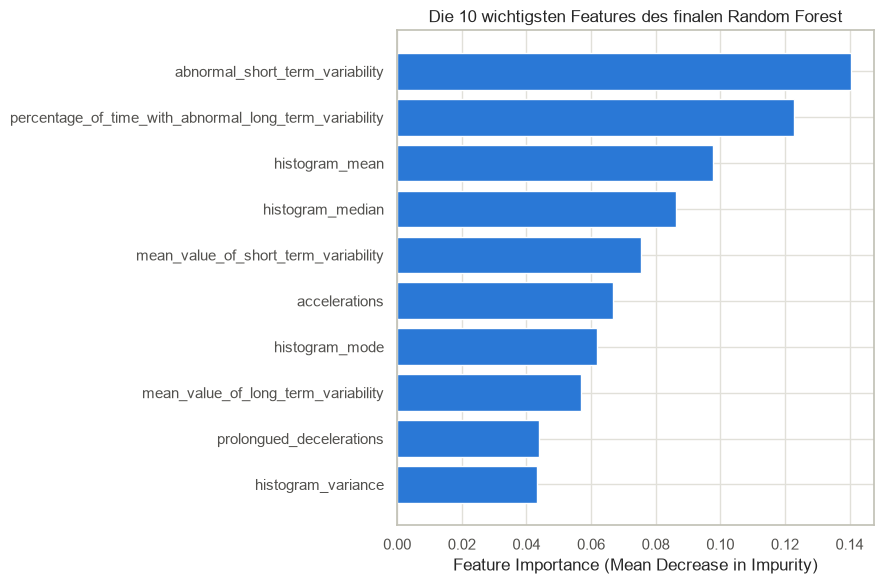

,Importance
abnormal_short_term_variability,0.1405
percentage_of_time_with_abnormal_long_term_variability,0.1229
histogram_mean,0.0976
histogram_median,0.0862
mean_value_of_short_term_variability,0.0756
accelerations,0.0668
histogram_mode,0.0617
mean_value_of_long_term_variability,0.0570
prolongued_decelerations,0.0439
histogram_variance,0.0434


In [89]:
importances = (pd.Series(final_model.feature_importances_, index=X.columns)
               .sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(9, 6))
top10 = importances.head(10).iloc[::-1]
ax.barh(top10.index, top10.values, color="#2a78d6")
ax.set_xlabel("Feature Importance (Mean Decrease in Impurity)")
ax.set_title("Die 10 wichtigsten Features des finalen Random Forest")
plt.tight_layout()
plt.show()

display(importances.head(10).round(4).to_frame("Importance"))

### Abgleich mit der Hypothese aus Schritt 1.8

Die Übereinstimmung ist hoch, vier unserer sechs vermuteten Kandidaten stehen in den Top 6.
`abnormal_short_term_variability` mit 0,141 und
`percentage_of_time_with_abnormal_long_term_variability` mit 0,123 sind auch für das Modell die
beiden wichtigsten Features, genau wie vermutet. Die Histogramm-Lageparameter folgen dicht
dahinter (`histogram_mean` 0,098, `histogram_median` 0,086, `histogram_mode` 0,062). Ihre
Wichtigkeit verteilt sich allerdings auf drei redundante Features mit r um 0,9 untereinander
(siehe ADR-005), ihr *gemeinsamer* Beitrag ist also größer, als jeder Einzelwert vermuten lässt.
Auch `accelerations` mit 0,067 bestätigt sich.

Eine Korrektur unserer Einschätzung müssen wir vornehmen: `prolongued_decelerations` hatte die
höchste Korrelation zur Zielvariable (r = +0,49), landet als Feature-Importance aber nur im
Mittelfeld. Der Grund liegt darin, dass das Feature in rund 92 % der Zeilen 0 ist. Es ist
hochspezifisch, aber zu selten, um viele Splits zu tragen. Umgekehrt gewinnt
`mean_value_of_short_term_variability` mit 0,076 an Bedeutung, obwohl seine Korrelation mit −0,10
unauffällig war. Das ist ein nichtlinearer Beitrag, den Pearson nicht sieht.

Das illustriert die Grenze der Korrelation als Vorauswahl-Heuristik und rechtfertigt nachträglich
die Entscheidung aus ADR-005, keine Features anhand der Korrelation zu entfernen.

## 6.9 Das Modell anwenden: Vorhersage für einen einzelnen Fall

Zum Abschluss schließen wir den Kreis und zeigen den Inferenzweg, wie er im Betrieb aussähe: Aus
den 21 CTG-Kennwerten eines einzelnen Falls entsteht eine Klassenaussage plus Wahrscheinlichkeiten.

Hier wird auch der `LabelEncoder` aus Schritt 2.4 zum ersten Mal rückwärts benutzt.
`inverse_transform` übersetzt den Integer-Code des Modells zurück in den ursprünglichen Wert der
Zielvariable, den wir über `CLASS_NAMES` in einen Klarnamen abbilden. Genau diese Rückübersetzung
ist der Grund, warum wir den Encoder aufgehoben haben: Ein Modell, das „2“ ausgibt, ist im
klinischen Alltag unbrauchbar.

In [90]:
# Stellvertretend für einen frisch aus dem Gerät kommenden Fall nehmen wir eine
# Zeile des Testsets. In der Praxis kämen die 21 Kennzahlen aus der CTG-Auswertung.
new_case = X_test.iloc[[0]]   # doppelte Klammern ergeben einen DataFrame, keine Series

predicted_code = final_model.predict(new_case)[0]
probabilities = final_model.predict_proba(new_case)[0]

original_value = label_encoder.inverse_transform([predicted_code])[0]
class_label = CLASS_NAMES[original_value]

print("Eingabe (Auszug der wichtigsten Merkmale):")
print(new_case[["abnormal_short_term_variability",
                "percentage_of_time_with_abnormal_long_term_variability",
                "accelerations"]].to_string(index=False))

print(f"\nVorhersage: Code {predicted_code} "
      f"-> fetal_health = {original_value} -> '{class_label}'")

print("\nWahrscheinlichkeiten je Klasse:")
for name, p in zip(TARGET_NAMES, probabilities):
    bar = "#" * int(round(p * 40))
    print(f"  {name:<14} {p:5.3f}  {bar}")

true_class = CLASS_NAMES[label_encoder.inverse_transform([y_test[0]])[0]]
print(f"\ntatsächliche Klasse: '{true_class}'  -> "
      f"{'korrekt' if class_label == true_class else 'FALSCH'}")

Eingabe (Auszug der wichtigsten Merkmale):
 abnormal_short_term_variability  percentage_of_time_with_abnormal_long_term_variability  accelerations
                            76.0                                                    29.0            0.0

Vorhersage: Code 0 -> fetal_health = 1.0 -> 'Normal'

Wahrscheinlichkeiten je Klasse:
  Normal         0.730  #############################
  Suspect        0.250  ##########
  Pathological   0.020  #

tatsächliche Klasse: 'Normal'  -> korrekt


Damit ist die Kette vollständig: von rohen CTG-Kennzahlen über das Modell und die
Wahrscheinlichkeiten bis zum Klassennamen. Für einen echten Produktiveinsatz käme genau an dieser
Stelle die Weiterverarbeitung hinzu, etwa die Anzeige der Wahrscheinlichkeiten für die befundende
Person statt nur der harten Klasse. Das entspricht unserer Empfehlung aus Schritt 7: Das Modell
liefert eine Einschätzung mit Unsicherheitsangabe, die ärztliche Entscheidung bleibt beim
Menschen.

---
# Schritt 7: Reflexion und Fazit

> **Hinweis der Gruppe:** Nach den Regeln des Assignments zur KI-Nutzung sind Interpretationen,
> Entscheidungsbegründungen und Reflexionen eigenständig zu verfassen, und die finale Empfehlung
> trifft die Gruppe. Die folgenden Abschnitte sind daher von uns formuliert und stützen sich auf
> die im Notebook berechneten Ergebnisse. KI-Werkzeuge haben wir, wie an den Codezellen
> gekennzeichnet, für Code und als Diskussionspartner genutzt, nicht als Autor dieser Bewertung.

Laut Assignment sind fünf Fragen zu beantworten:

1. Welches Modell empfehlen wir für den Produktiveinsatz, und warum?
2. Was hat uns im Verlauf der Arbeit überrascht?
3. Wo sehen wir Grenzen des besten Modells im Praxiskontext?
4. Was würden wir mit mehr Zeit, mehr Daten oder mehr Ressourcen anders machen?
5. Bonusfrage: Hätte ein CNN oder Transfer Learning hier geholfen?

## 7.1 Statistische Einordnung der Testergebnisse

Bevor wir bewerten, quantifizieren wir die Unsicherheit unserer Testmetriken. Bei 317
Testsamples, davon nur 26 pathologischen, sind Punktschätzer allein irreführend. Wir berechnen
daher 95-%-Wilson-Konfidenzintervalle, die auch bei kleinen Stichproben und Anteilen nahe 0
oder 1 verlässlich sind.

In [91]:
import math


def wilson_interval(k, n, z=1.96):
    """95-%-Konfidenzintervall für einen Anteil k/n nach Wilson.

    Robuster als das Normal-Approximationsintervall, wenn n klein ist oder
    der Anteil nahe 0 bzw. 1 liegt (hier: Recall 26/26 = 1.0).
    """
    p = k / n
    denominator = 1 + z**2 / n
    center = (p + z**2 / (2 * n)) / denominator
    margin = z * math.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / denominator
    return max(0.0, center - margin), min(1.0, center + margin)


# Treffer je Klasse aus der Diagonale der Konfusionsmatrix
rows = []
for i, name in enumerate(TARGET_NAMES):
    n_correct, n_total = cm[i, i], cm[i].sum()
    lo, hi = wilson_interval(n_correct, n_total)
    rows.append({"Klasse": name, "korrekt": f"{n_correct}/{n_total}",
                 "Recall": round(n_correct / n_total, 3),
                 "95-%-KI": f"[{lo:.3f}, {hi:.3f}]"})

n_correct_total = int(np.trace(cm))
lo, hi = wilson_interval(n_correct_total, int(cm.sum()))
rows.append({"Klasse": "Accuracy gesamt", "korrekt": f"{n_correct_total}/{cm.sum()}",
             "Recall": round(n_correct_total / cm.sum(), 3),
             "95-%-KI": f"[{lo:.3f}, {hi:.3f}]"})

display(pd.DataFrame(rows).set_index("Klasse"))

,korrekt,Recall,95-%-KI
Klasse,,,
Normal,235/247,0.951,"[0.917, 0.972]"
Suspect,33/44,0.750,"[0.606, 0.854]"
Pathological,26/26,1.000,"[0.871, 1.000]"
Accuracy gesamt,294/317,0.927,"[0.893, 0.951]"


Die Intervalle zeigen deutlich, wie unterschiedlich belastbar unsere Zahlen sind.

Bei Pathological liegt der Recall bei 1,000, das Konfidenzintervall reicht aber bis 0,871
hinunter. „26 von 26 erkannt“ ist also mit einem wahren Recall von 90 % gut vereinbar, und wir
dürfen deshalb nicht von einer perfekten Erkennung sprechen. Bei Suspect liegt der Recall bei
0,750 mit einem sehr breiten Intervall von 0,606 bis 0,854; bei 44 Fällen ist selbst die Aussage
„drei Viertel werden erkannt“ nur grob. Am stabilsten ist die Gesamt-Accuracy mit 0,927 und einem
Intervall von 0,893 bis 0,951, weil hier alle 317 Samples einfließen.

Diese Unsicherheit ziehen wir in allen folgenden Bewertungen mit.

## 7.2 Welches Modell empfehlen wir für den Produktiveinsatz, und warum?

**Unsere Empfehlung ist der Random Forest mit `class_weight="balanced"`**, allerdings
ausdrücklich als Assistenzsystem mit ärztlicher Letztentscheidung und nicht als autonome
Diagnose.

Die Gründe, in der Reihenfolge ihres Gewichts für uns:

1. **Er ist auf der klinisch entscheidenden Klasse am stärksten.** Kein pathologischer Fall des
   Testsets wurde als Normal durchgewinkt; in der Zeile *Pathological* steht in der Spalte
   *pred: Normal* eine 0. Genau dieser Fehler wäre der einzige mit potenziell gravierenden Folgen.
   Die Alternativmodelle übersahen auf dem Validierungsset, auf dem alle fünf Modelle
   verglichen wurden, jeweils 8 bis 9 der dortigen 26 Fälle.
2. **Er ist in allen Metriken gleichzeitig vorn.** Wir mussten also nicht zwischen Accuracy und
   Minderheitsklassen-Recall abwägen, was die Entscheidung robust macht.
3. **Sein Fehlerprofil passt zum Anwendungsfall.** Die verbleibenden Fehler sind überwiegend
   *vorsichtige* Fehler, nämlich 12-mal Normal zu Suspect und 2-mal Suspect zu Pathological. Sie
   erzeugen Prüfaufwand, keinen Schaden.
4. **Er ist praktisch handhabbar.** Das Training dauert unter einer Sekunde, eine GPU ist nicht
   nötig, eine Skalierung entfällt (ein Vorverarbeitungsschritt weniger, der im Betrieb
   schiefgehen kann), und über die Feature Importances ist er teilweise erklärbar. In der Medizin
   ist das ein reales Argument, weil ärztliches Personal nachvollziehen können muss, worauf ein
   Alarm beruht.

**Wogegen wir uns bewusst entschieden haben:** Die neuronalen Netze bringen bei diesem
Datenformat keinen Vorteil, mit F1w 0,886 beziehungsweise 0,909 gegenüber 0,945, kosten aber
deutlich mehr Trainingszeit, sind schlechter erklärbar und bringen mit Keras und TensorFlow eine
schwergewichtige Abhängigkeit in den Betrieb. Für einen Produktiveinsatz ist das ein schlechtes
Tauschgeschäft.

**Eine wichtige Einschränkung zu unserer eigenen Empfehlung:** Der Unterschied zwischen Random
Forest und den übrigen Modellen ist bei der Accuracy substanziell, beim Pathological-Recall aber
statistisch weniger sicher, als die Punktschätzer suggerieren. 26 Testfälle sind schlicht wenig.
Wir empfehlen den Random Forest, weil er in *jeder* Auswertung vorn lag, also in
Kreuzvalidierung, Validierung und Test, und nicht wegen eines einzelnen Zahlenvorsprungs.

## 7.3 Was hat uns im Verlauf der Arbeit überrascht?

**Dass die neuronalen Netze verloren haben.** Wir waren davon ausgegangen, dass das modernere
Verfahren gewinnt. Tatsächlich lag selbst die optimierte Variante B mit F1w 0,909 klar hinter
einem Random Forest mit Default-Parametern und 0,945. Rückblickend ist das plausibel: 1.479
Trainingsbeispiele mit 21 vorverarbeiteten Merkmalen sind genau die Situation, für die
Baumensembles gebaut sind, während ein MLP seine Stärke, nämlich das Lernen von Repräsentationen
aus rohen, hochdimensionalen Daten, hier gar nicht ausspielen kann. Die Lehre für uns: Die
Modellwahl folgt der Datenform und nicht der Aktualität des Verfahrens.

**Dass die *tiefere* Variante B zunächst schlechter war als die flache Variante A.** Mehr
Schichten plus Regularisierung klang nach einer sicheren Verbesserung, tatsächlich trat das
Gegenteil ein (F1w 0,877 gegenüber 0,886). Erst die Analyse der Lernkurven zeigte, dass nicht die
Architektur schuld war, sondern der Optimierer: Mit reinem SGD blieb das Training in einem flachen
Bereich stecken, den Early Stopping als Konvergenz missdeutete. Ein einziger Zusatz,
`momentum=0.9`, drehte das Ergebnis auf 0,909. Uns hat überrascht, wie stark der Optimierer den
Architektureffekt überlagert, und wie leicht man daraus die falsche Schlussfolgerung „die
Architektur taugt nichts“ gezogen hätte.

**Dass das *stärkste* Korrelations-Feature im Modell nur Mittelmaß ist.**
`prolongued_decelerations` hatte mit r = +0,49 die höchste Korrelation zur Zielvariable, landet
bei den Feature Importances aber nur auf Platz 9, weil es in 92 % der Zeilen 0 ist und damit zu
wenige Splits trägt. Umgekehrt wurde `mean_value_of_short_term_variability` mit einer
unauffälligen Korrelation von −0,10 zum fünftwichtigsten Feature. Das hat uns vor Augen geführt,
wie begrenzt die Pearson-Korrelation als Auswahlheuristik ist, und hat nachträglich unsere
Entscheidung bestätigt, keine Features vorab zu entfernen (siehe ADR-005).

**Wie viel der `classification_report` gegenüber der Accuracy verbirgt.** Accuracy 0,927 klingt
gleichmäßig gut. Tatsächlich schwankt das F1 je Klasse zwischen 0,742 bei Suspect und 0,963 bei
Pathological. Ohne die klassenweise Aufschlüsselung hätten wir die eigentliche Schwachstelle des
Modells überhaupt nicht bemerkt.

## 7.4 Wo sehen wir Grenzen des besten Modells im Praxiskontext?

**Die Klasse Suspect ist die eigentliche Schwachstelle.** Mit Recall 0,750 und Precision 0,733
ist sie von beiden Seiten unzuverlässig, und ausgerechnet sie ist klinisch am ehesten
handlungsleitend, denn es geht um die Frage „beobachten oder nicht?“. 9 von 44 Suspect-Fällen
werden als unauffällig eingestuft und fielen damit aus der Nachbeobachtung. Wir halten das für die
wichtigste offene Baustelle. Fachlich ist die Ursache nachvollziehbar: Suspect ist
definitionsgemäß der Graubereich zwischen normal und pathologisch, und schon die explorative
Analyse in Schritt 1.7 zeigte starke Überlappung mit beiden Nachbarklassen.

**Die Datenbasis ist für belastbare Aussagen zur kritischen Klasse zu klein.** 26 pathologische
Testfälle erlauben kein Qualitätsversprechen, das Konfidenzintervall reicht bis 0,871 hinunter
(siehe 7.1). Für einen echten klinischen Einsatz wäre das keine ausreichende Evidenzbasis.

**Es gibt keine Aussage zur Übertragbarkeit auf andere Kliniken.** Alle Daten stammen aus einer
Quelle und wurden nach einem einheitlichen Verfahren gelabelt. Ob das Modell auf CTG-Geräten
anderer Hersteller, bei anderen Patientinnenpopulationen oder bei abweichender Befundungspraxis
ähnlich funktioniert, ist ungeprüft. Erfahrungsgemäß brechen medizinische ML-Modelle genau an
dieser Stelle ein, Stichwort Distribution Shift.

**Das Modell lernt Befundungsverhalten, nicht den fetalen Zustand.** Die Labels sind ärztliche
Einschätzungen des CTG und nicht der tatsächliche Ausgang der Geburt. Das Modell reproduziert
damit bestenfalls die Urteilsqualität der Befundenden einschließlich deren systematischer Fehler.
Ein Modell mit perfektem Recall hätte gelernt, Ärztinnen und Ärzte zu imitieren, nicht, Kindern
zu helfen. Für eine Aussage über den klinischen Nutzen bräuchte man Outcome-Daten wie Apgar-Score
oder Nabelschnur-pH, die hier nicht vorliegen.

**Es fehlen Kalibrierung und Zeitbezug.** Wir haben nur harte Klassenzuweisungen bewertet. Für den
Betrieb wäre wichtig, ob die Wahrscheinlichkeiten aus `predict_proba` kalibriert sind, damit man
Schwellen fachlich setzen kann. Außerdem beschreibt jede Zeile ein *aggregiertes* CTG; der
zeitliche Verlauf, den Ärztinnen und Ärzte tatsächlich beurteilen, ist in den Merkmalen bereits
weggerechnet.

**Es bleiben Verantwortungs- und Regulierungsfragen.** Ein solches System wäre ein Medizinprodukt
und unterläge entsprechenden Zulassungs- und Dokumentationspflichten. Zudem besteht die Gefahr des
Automation Bias, dass also ein unauffälliges Modellergebnis die eigene kritische Prüfung ersetzt.
Beides spricht dafür, das Modell strikt als Zweitmeinung zu positionieren.

## 7.5 Was würden wir mit mehr Zeit, mehr Daten oder mehr Ressourcen anders machen?

### Mit mehr Daten, unserem wichtigsten Hebel

Bevor wir mehr Daten fordern, prüfen wir empirisch, ob mehr *Trainings*daten das Modell überhaupt
besser machen würden. Dazu dient sklearns `learning_curve`: Sie trainiert dasselbe Modell
wiederholt auf wachsenden Teilmengen und misst jeweils per Kreuzvalidierung.

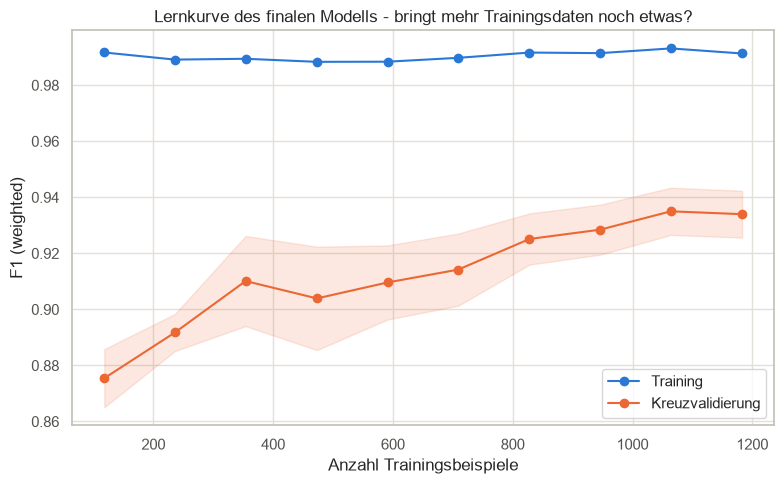

F1w bei  118 Beispielen: 0.8754
F1w bei 1183 Beispielen: 0.9340
Zuwachs insgesamt:            +0.0585
Zuwachs durch die letzten 30 % der Daten: +0.0088
typische CV-Streuung (Std):   ±0.0084


In [92]:
# Quelle: Claude
from sklearn.model_selection import learning_curve

# sample_sizes bezeichnet die tatsächlich pro CV-Trainingsteil verwendete Anzahl,
# nicht die Gesamtgröße von X_train.
sample_sizes, train_scores, cv_scores = learning_curve(
    RandomForestClassifier(random_state=RANDOM_STATE, **final_params),
    X_train, y_train, cv=cv, scoring="f1_weighted",
    train_sizes=np.linspace(0.1, 1.0, 10), n_jobs=-1, random_state=RANDOM_STATE)

cv_mean, cv_std = cv_scores.mean(axis=1), cv_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(sample_sizes, train_scores.mean(axis=1), marker="o", color="#2a78d6", label="Training")
ax.plot(sample_sizes, cv_mean, marker="o", color="#eb6834", label="Kreuzvalidierung")
ax.fill_between(sample_sizes, cv_mean - cv_std, cv_mean + cv_std, color="#eb6834", alpha=0.15)
ax.set_xlabel("Anzahl Trainingsbeispiele")
ax.set_ylabel("F1 (weighted)")
ax.set_title("Lernkurve des finalen Modells - bringt mehr Trainingsdaten noch etwas?")
ax.legend()
plt.tight_layout()
plt.show()

print(f"F1w bei {sample_sizes[0]:>4} Beispielen: {cv_mean[0]:.4f}")
print(f"F1w bei {sample_sizes[-1]:>4} Beispielen: {cv_mean[-1]:.4f}")
print(f"Zuwachs insgesamt:            {cv_mean[-1] - cv_mean[0]:+.4f}")
print(f"Zuwachs durch die letzten 30 % der Daten: {cv_mean[-1] - cv_mean[-4]:+.4f}")
print(f"typische CV-Streuung (Std):   ±{cv_std[-1]:.4f}")

**Was die Lernkurve zeigt:** Von 118 auf 1.183 Trainingsbeispiele steigt der F1w deutlich, um
0,059. Die letzten 30 % der Daten bringen aber nur noch 0,009, und das liegt in derselben
Größenordnung wie die CV-Streuung von ± 0,008 und ist damit kaum von Rauschen zu unterscheiden.
Die Kurve ist also stark abgeflacht, aber noch nicht vollständig im Plateau.

Daraus folgt eine differenzierte Antwort, die wir vorher so nicht hatten. Mehr Trainingsdaten
würden die Modellqualität nur noch geringfügig verbessern, vermutlich im Bereich weniger
Zehntel-Prozentpunkte. Der Trainings-Score liegt über alle Größen hinweg bei etwa 0,99, der
Random Forest lernt die Trainingsdaten also unabhängig von ihrer Menge auswendig, wie schon in
6.2 zu sehen war, und die Lücke zur CV-Kurve schließt sich nur langsam. Der eigentliche Gewinn von
mehr Daten läge deshalb nicht in einem besseren Modell, sondern in einer belastbareren Messung und
in mehr Fällen der kleinen Klassen, an denen derzeit jede Aussage hängt.

Für die Messgenauigkeit haben wir überschlagen, wie viele pathologische Fälle das Testset
bräuchte:

| gewünschte Präzision | benötigte Pathological-Fälle im Testset | entspricht Gesamtdatensatz |
|---|---|---|
| ± 10 Prozentpunkte | ca. 19 | ca. 1.500 Samples (heute erfüllt) |
| ± 5 Prozentpunkte | ca. 73 | ca. 5.900 Samples |
| ± 3 Prozentpunkte | ca. 203 | ca. 16.300 Samples |

*(Normal-Approximation bei p = 0,95, 95-%-Niveau, 8,3 % Klassenanteil, 15 % Testanteil.)*

Wir bräuchten also grob das Dreifache der heutigen Datenmenge für halbwegs belastbare Aussagen,
und Daten aus mehreren Kliniken, um Übertragbarkeit überhaupt prüfen zu können.

### Mit mehr Zeit: methodische Verbesserungen, nach erwartetem Nutzen sortiert

1. **Wiederholte oder geschachtelte Kreuzvalidierung.** Unsere Modellauswahl beruht auf einem
   einzigen Split. Eine Auswertung mit `RepeatedStratifiedKFold` würde zeigen, wie stabil der
   Vorsprung des Random Forest wirklich ist; Nested CV würde zusätzlich die Optimismus-Verzerrung
   durch die Hyperparameter-Suche beseitigen.
2. **Schwellenwert nach fachlichen Fehlerkosten setzen.** Die Analyse haben wir in Abschnitt 6.3
   bereits durchgeführt und uns bewusst gegen eine Verschiebung entschieden, weil der Gewinn bei
   26 Validierungsfällen im Rauschen liegt (siehe ADR-016). Mit einer belastbaren Kostenangabe
   („ein übersehener Fall entspricht X Fehlalarmen“) und mehr Fällen ließe sich der Arbeitspunkt
   dagegen sauber optimieren. Aus unserer Sicht ist das der Hebel mit dem besten Verhältnis von
   Aufwand zu klinischem Nutzen.
3. **Gezielte Arbeit an der Klasse Suspect**, etwa über ein zweistufiges Vorgehen: erst
   „unauffällig gegen auffällig“, dann innerhalb der auffälligen Fälle differenzieren.
4. **Modellkalibrierung** prüfen und gegebenenfalls mit `CalibratedClassifierCV` korrigieren.
5. **XGBoost oder LightGBM** als Alternative testen. Bei tabellarischen Daten sind sie häufig noch
   etwas stärker als ein Random Forest, was wir aus Zeit- und Abhängigkeitsgründen nicht getan
   haben.
6. **Erklärbarkeit vertiefen.** Feature Importances sind global, SHAP-Werte würden pro Einzelfall
   zeigen, *warum* ein CTG als pathologisch gilt. Für die ärztliche Akzeptanz ist das vermutlich
   wichtiger als ein weiterer Prozentpunkt Accuracy.

### Mit mehr Ressourcen

Rechenleistung war hier ausdrücklich nicht der Engpass, der gesamte GridSearch lief in unter 10
Sekunden. Zusätzliche GPU-Kapazität würde an unserem Ergebnis nichts ändern. Der Engpass ist die
Datenmenge und die fachliche Validierung, nicht die Hardware. Das war für uns eine der
nützlichsten Erkenntnisse des Projekts.

## 7.6 Bonusfrage: Hätte ein CNN oder Transfer Learning hier geholfen?

**Auf unseren Daten: nein, und zwar aus einem strukturellen Grund.**

Ein CNN nutzt aus, dass benachbarte Eingabewerte räumlich oder zeitlich zusammenhängen. Bei einem
Bild sind benachbarte Pixel Teil derselben Kante, bei einem Zeitsignal benachbarte Messpunkte Teil
desselben Verlaufs. Genau diese Nachbarschaft existiert in unseren Daten nicht. Unsere 21 Spalten
sind eine ungeordnete Menge aggregierter Kennzahlen; man könnte `histogram_width` und
`accelerations` vertauschen, ohne dass sich inhaltlich etwas ändert. Ein Faltungskern über diese
Spalten würde Nachbarschaften auswerten, die es gar nicht gibt.

Auch Transfer Learning hilft hier nicht. Vortrainierte Netze aus ImageNet oder Sprachmodelle haben
Repräsentationen für Bilder oder Text gelernt. Für 21 CTG-Kennzahlen gibt es kein sinnvolles
vortrainiertes Modell, dessen Merkmalsraum zu unserem passt.

**Wo beides sehr wohl helfen könnte, nämlich auf anderen Daten:**

Der entscheidende Punkt ist, dass unsere Merkmale bereits das Ergebnis einer Vorverarbeitung sind.
Aus dem ursprünglichen CTG-Zeitsignal, also Herzfrequenz und Wehen über Minuten hinweg, wurden von
Menschen definierte Kennzahlen berechnet. Auf dem rohen Zeitsignal wäre ein 1D-CNN die
naheliegende Architektur. Es könnte Muster lernen, die in keiner der 21 Kennzahlen abgebildet
sind, etwa die zeitliche Kopplung zwischen einer Wehe und der darauf folgenden Dezeleration.
Klinisch ist das der Unterschied zwischen frühen und späten Dezelerationen und für die
Beurteilung zentral. Diese Information ist in unserem aggregierten Datensatz unwiederbringlich
verloren.

Ebenso wäre Transfer Learning dort denkbar: ein Modell, das auf großen Mengen unbeschrifteter
CTG-Aufzeichnungen selbstüberwacht vortrainiert und anschließend auf die kleine gelabelte Menge
feinabgestimmt wird. Das wäre ein plausibler Weg, das Problem der nur 175 pathologischen Fälle zu
entschärfen.

**Unser Fazit zur Bonusfrage:** Nicht das Verfahren entscheidet, sondern die Datenform. Für
tabellarische, aggregierte Merkmale in dieser Größenordnung sind Baumensembles die angemessene
Wahl. Deep Learning würde erst dann interessant, wenn wir eine Ebene tiefer gingen und mit den
Rohsignalen arbeiteten.

## 7.7 Gesamtfazit

Wir haben fünf Modelle nach einem einheitlichen, leakage-freien Protokoll verglichen: Duplikate
vor dem Split entfernt, stratifiziert 70/15/15 geteilt, den Scaler ausschließlich auf den
Trainingsdaten gefittet, alle Modellentscheidungen über Kreuzvalidierung und Validierungsset
getroffen und das Testset genau einmal angefasst.

**Ergebnis:** Ein Random Forest mit ausgeglichenen Klassengewichten erreicht auf dem Testset
Accuracy 0,927 und F1 (weighted) 0,928 und erkennt alle 26 pathologischen Fälle. Er schlägt beide
neuronalen Netze deutlich.

**Was wir methodisch mitnehmen:** Die wichtigsten Erkenntnisse des Projekts kamen nicht aus der
besten Zahl, sondern aus dem genauen Hinsehen. Die Konfusionsmatrix zeigte die Schwäche bei
Suspect, die die Accuracy verdeckte. Die Lernkurven zeigten, dass Variante B am Optimierer
scheiterte und nicht an der Architektur. Die Feature Importances korrigierten unsere
Korrelations-Hypothese aus der explorativen Analyse. Und die Konfidenzintervalle machten deutlich,
dass unser bestes Einzelergebnis, ein Recall von 1,000, die am wenigsten belastbare Zahl des
gesamten Projekts ist.

Für einen realen Einsatz wäre dieses Modell ein Kandidat für eine Assistenzfunktion mit ärztlicher
Letztentscheidung, kein fertiges Diagnosewerkzeug. Der Weg dorthin führt über mehr Daten aus
mehreren Kliniken und über eine Validierung an tatsächlichen Geburtsausgängen, nicht über ein
größeres Modell.